# Model 3 - WaveUNet 

In [52]:
import subprocess, sys

def _pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'],stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for _pkg in ['medpy', 'albumentations', 'PyWavelets']:
    try:
        __import__(_pkg.lower().replace('-','_'))
    except ImportError:
        print(f'Installing {_pkg}…')
        _pip_install(_pkg)


Installing PyWavelets…


In [2]:
import os, random, warnings, time, math
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
import cv2
import pywt                          
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import albumentations as A
from albumentations.pytorch import ToTensorV2
from medpy.metric.binary import hd95 as compute_hd95

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 9})

print(f'  PyTorch    : {torch.__version__}')
print(f'  PyWavelets : {pywt.__version__}')
print(f'  CUDA       : {torch.cuda.is_available()} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})')

  PyTorch    : 2.10.0+cu128
  PyWavelets : 1.8.0
  CUDA       : True (Tesla T4)


In [3]:
class CFG:
    SEED = 67
    IMAGE_SIZE = 224
    BATCH_SIZE = 8
    LR = 3e-4
    WARMUP_EPOCHS = 5
    EPOCHS = 100
    WEIGHT_DECAY = 1e-5
    FOCAL_ALPHA = 0.25
    FOCAL_GAMMA = 2.0
    FOCAL_WEIGHT = 0.4
    DICE_WEIGHT = 0.6
    WAVELET = 'haar'
    WAVE_LEVELS = 4
    BASE_CH = 32
    IN_CHANNELS = 4
    OUT_CHANNELS = 1
    DATA_ROOT = Path('/kaggle/input/datasets/prabhanshu22/dac-dataset-skull/processed_skull')
    TRAIN_DIR = DATA_ROOT / 'train'
    VAL_DIR = DATA_ROOT / 'val'
    TEST_DIR = DATA_ROOT / 'test'
    CKPT_DIR = Path('/kaggle/working/models')
    BEST_CKPT = CKPT_DIR / 'waveunet_best.pth'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(CFG.SEED)
CFG.CKPT_DIR.mkdir(parents=True, exist_ok=True)

ch = [CFG.BASE_CH * (2**i) for i in range(CFG.WAVE_LEVELS+1)]
print(f'Config  |  Device: {CFG.DEVICE}  |  Seed: {CFG.SEED}')
print(f'Wavelet : {CFG.WAVELET}  |  Levels: {CFG.WAVE_LEVELS}')
print(f'Channels: {ch}')
print(f'Input ch: {CFG.IN_CHANNELS} (1 original + 3 wavelet detail bands)')


Config  |  Device: cuda  |  Seed: 67
Wavelet : haar  |  Levels: 4
Channels: [32, 64, 128, 256, 512]
Input ch: 4 (1 original + 3 wavelet detail bands)


## Loading the Data 

In [ ]:
def compute_wavelet_channels(img_2d: np.ndarray, wavelet: str = 'haar') -> np.ndarray:
    LL, (LH, HL, HH) = pywt.dwt2(img_2d, wavelet)

    def norm(x, target_shape):
        x = cv2.resize(x.astype(np.float32), (target_shape[1], target_shape[0]),interpolation=cv2.INTER_LINEAR)
        mn, mx = x.min(), x.max()
        return (x - mn) / (mx - mn + 1e-8)
    H, W = img_2d.shape
    return np.stack([img_2d,norm(LH, (H,W)),norm(HL, (H,W)),norm(HH, (H,W)),], axis=0).astype(np.float32)

class BRISCDataset(Dataset):
    def __init__(self, split_dir: Path, transform=None):
        self.transform = transform
        self.wavelet = CFG.WAVELET
        self.image_paths = sorted((split_dir / 'images').glob('*.npy'))
        self.mask_paths = [split_dir / 'masks' / p.name for p in self.image_paths]
        missing = [p for p in self.mask_paths if not p.exists()]
        assert not missing, f'Missing {len(missing)} masks — first: {missing[0]}'

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = np.load(self.image_paths[idx]).astype(np.float32)
        mask = np.load(self.mask_paths[idx]).astype(np.float32)

        if img.ndim == 3:
            img = img[..., 0] if img.shape[-1] <= 4 else img[0]

        mn, mx = img.min(), img.max()
        img = (img - mn) / (mx - mn + 1e-8)
        mask_2d = (mask > 0.5).astype(np.float32)
        img_3ch = np.stack([img, img, img], axis=-1) 
        
        if self.transform:
            out = self.transform(image=img_3ch, mask=mask_2d)
            img_aug = out['image'][0].numpy()
            mask_t = out['mask'].unsqueeze(0).float()
        else:
            img_aug = img
            mask_t = torch.from_numpy(mask_2d).unsqueeze(0)

        wave_ch = compute_wavelet_channels(img_aug, self.wavelet)
        img_t = torch.from_numpy(wave_ch)
        return img_t, mask_t

In [5]:
SZ = CFG.IMAGE_SIZE

def get_train_transforms():
    return A.Compose([
        A.Resize(SZ, SZ),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,rotate_limit=15, p=0.5),
        A.ElasticTransform(alpha=120, sigma=6, alpha_affine=6, p=0.4),
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.15,contrast_limit=0.15, p=0.4),
        A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
        A.Normalize(mean=(0.0,), std=(1.0,)),
        ToTensorV2(),])

def get_val_transforms():
    return A.Compose([
        A.Resize(SZ, SZ),
        A.Normalize(mean=(0.0,), std=(1.0,)),
        ToTensorV2(),])

In [6]:
train_ds = BRISCDataset(CFG.TRAIN_DIR,transform=get_train_transforms())
val_ds = BRISCDataset(CFG.VAL_DIR,transform=get_val_transforms())
test_ds = BRISCDataset(CFG.TEST_DIR,transform=get_val_transforms())

_kw = dict(batch_size=CFG.BATCH_SIZE, num_workers=2, pin_memory=True)
train_loader = DataLoader(train_ds,shuffle=True,  **_kw)
val_loader = DataLoader(val_ds,shuffle=False, **_kw)
test_loader = DataLoader(test_ds,shuffle=False, **_kw)

print(f'Train : {len(train_ds):>5} slices  ({len(train_loader):>4} batches)')
print(f'Val   : {len(val_ds):>5} slices  ({len(val_loader):>4} batches)')
print(f'Test  : {len(test_ds):>5} slices  ({len(test_loader):>4} batches)')

imgs, masks = next(iter(train_loader))
print(f'\nBatch : image {tuple(imgs.shape)}  mask {tuple(masks.shape)}')
print(f'Channel meanings : [0]=original  [1]= LH edges  [2]= HL edges  [3]= HH detail')
print(f'Image range [{imgs.min():.3f}, {imgs.max():.3f}]  |  Mask unique {masks.unique().tolist()}')

Train :  3343 slices  ( 418 batches)
Val   :   590 slices  (  74 batches)
Test  :   860 slices  ( 108 batches)

Batch : image (8, 4, 224, 224)  mask (8, 1, 224, 224)
Channel meanings : [0]=original  [1]= LH edges  [2]= HL edges  [3]= HH detail
Image range [0.000, 1.000]  |  Mask unique [0.0, 1.0]


## Architecture — WaveUNet

In [ ]:
# DWT Downsampling
class DWTDownsample(nn.Module):
    def __init__(self):
        super().__init__()
        h = torch.tensor([[[[ 1,  1],[ 1,  1]]],
                           [[[ 1,  1],[-1, -1]]],
                           [[[ 1, -1],[ 1, -1]]],
                           [[[ 1, -1],[-1,  1]]]], dtype=torch.float32) / 2.0
        self.register_buffer('filters', h)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        out = F.conv2d(x.reshape(B * C, 1, H, W), self.filters, stride=2)
        return out.reshape(B, C * 4, H // 2, W // 2)


# IDWT Upsampling
class IDWTUpsample(nn.Module):
    def __init__(self):
        super().__init__()
        h = torch.tensor([[[[ 1,  1],[ 1,  1]]],
                           [[[ 1,  1],[-1, -1]]],
                           [[[ 1, -1],[ 1, -1]]],
                           [[[ 1, -1],[-1,  1]]]], dtype=torch.float32) / 2.0
        self.register_buffer('filters', h)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C4, H, W = x.shape
        C = C4 // 4
        out = F.conv_transpose2d(x.reshape(B * C, 4, H, W), self.filters, stride=2)
        return out.reshape(B, C, H * 2, W * 2)


# Double Conv Block
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),)
    def forward(self, x): return self.block(x)


# Encoder Block 
class WaveEncoderBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.down = DWTDownsample()

    def forward(self, x):
        skip = self.conv(x)
        down = self.down(skip)
        return down, skip

# Decoder Block
class WaveDecoderBlock(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, out_ch * 4, kernel_size=1, bias=False)
        self.up = IDWTUpsample()
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.proj(x)
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            skip = F.interpolate(skip, size=x.shape[2:],mode='bilinear', align_corners=True)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


print('WaveUNet building blocks defined')
print('DWTDownsample  : lossless pooling  (4C, H/2, W/2) — 0 learned parameters')
print('IDWTUpsample   : exact reconstruction (C, 2H, 2W) — 0 learned parameters')
print('WaveDecoderBlock: proj(1x1) -> IDWT -> cat skip -> DoubleConv')

WaveUNet building blocks defined
DWTDownsample  : lossless pooling  (4C, H/2, W/2) — 0 learned parameters
IDWTUpsample   : exact reconstruction (C, 2H, 2W) — 0 learned parameters
WaveDecoderBlock: proj(1x1) -> IDWT -> cat skip -> DoubleConv


In [ ]:
# Full WaveUNet Model 
class WaveUNet(nn.Module):
    def __init__(self,
                 in_ch:   int = CFG.IN_CHANNELS,
                 out_ch:  int = CFG.OUT_CHANNELS,
                 base_ch: int = CFG.BASE_CH):
        super().__init__()
        b = base_ch

        # Encoder 
        self.enc0 = WaveEncoderBlock(in_ch, b)
        self.enc1 = WaveEncoderBlock(b*4,   b*2)
        self.enc2 = WaveEncoderBlock(b*8,   b*4)
        self.enc3 = WaveEncoderBlock(b*16,  b*8)

        # Bottleneck
        self.bottleneck = DoubleConv(b*32, b*16)

        # Decoder 
        self.dec3 = WaveDecoderBlock(b*16, b*8,  b*8)
        self.dec2 = WaveDecoderBlock(b*8,  b*4,  b*4)
        self.dec1 = WaveDecoderBlock(b*4,  b*2,  b*2)
        self.dec0 = WaveDecoderBlock(b*2,  b,    b)
        
        # Segmentation head
        self.head = nn.Conv2d(b, out_ch, kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder
        d0, s0 = self.enc0(x)
        d1, s1 = self.enc1(d0)
        d2, s2 = self.enc2(d1)
        d3, s3 = self.enc3(d2)
        
        # Bottleneck
        b  = self.bottleneck(d3)

        # Decoder
        d  = self.dec3(b,  s3)
        d  = self.dec2(d,  s2)
        d  = self.dec1(d,  s1)
        d  = self.dec0(d,  s0)

        return self.head(d)

In [ ]:
model = WaveUNet().to(CFG.DEVICE)

def count_params(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

def print_param_summary(m):
    hdr = f"{'Module':<20} {'Type':<25} {'Params':>12}"
    print('─' * len(hdr))
    print(hdr)
    print('─' * len(hdr))
    for name, mod in m.named_children():
        p = sum(x.numel() for x in mod.parameters())
        print(f'{name:<20} {type(mod).__name__:<25} {p:>12,}')
    print('─' * len(hdr))
    tot, trn = count_params(m)
    print(f"{'Total':<20} {'':.<25} {tot:>12,}")
    print(f"{'Trainable':<20} {'':.<25} {trn:>12,}")
    print('─' * len(hdr))

print_param_summary(model)
tot, _ = count_params(model)
print(f'\n  ≈ {tot/1e6:.1f} M parameters')

with torch.no_grad():
    dummy = torch.randn(2, CFG.IN_CHANNELS, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE).to(CFG.DEVICE)
    out = model(dummy)

───────────────────────────────────────────────────────────
Module               Type                            Params
───────────────────────────────────────────────────────────
enc0                 WaveEncoderBlock                10,496
enc1                 WaveEncoderBlock               110,848
enc2                 WaveEncoderBlock               442,880
enc3                 WaveEncoderBlock             1,770,496
bottleneck           DoubleConv                   7,079,936
dec3                 WaveDecoderBlock             2,294,784
dec2                 WaveDecoderBlock               573,952
dec1                 WaveDecoderBlock               143,616
dec0                 WaveDecoderBlock                35,968
head                 Conv2d                              33
───────────────────────────────────────────────────────────
Total                .........................   12,463,009
Trainable            .........................   12,463,009
────────────────────────────────────────

Wavelet channels visualised — note how LH/HL highlight tumour boundaries



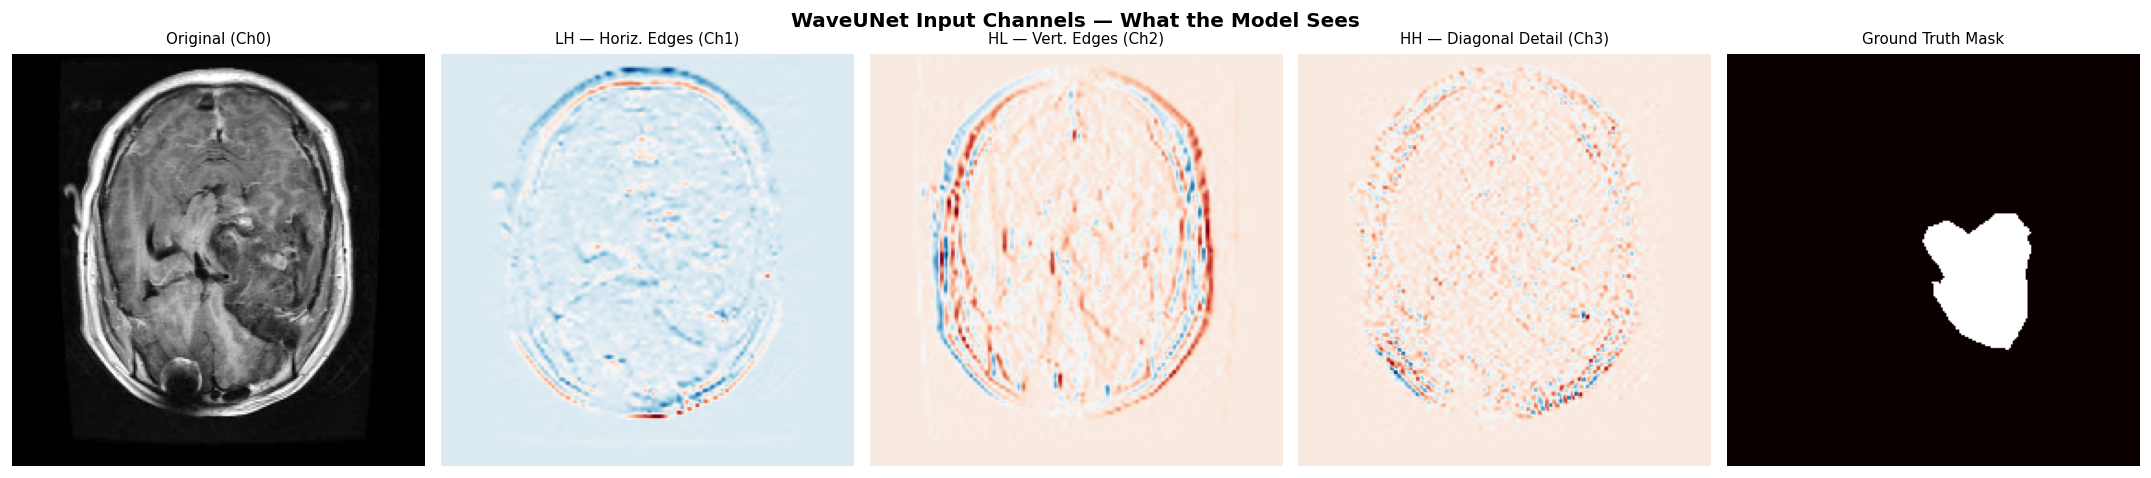

In [ ]:
print('Wavelet channels visualised — note how LH/HL highlight tumour boundaries\n')

sample_img, sample_mask = train_ds[0] 
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('WaveUNet Input Channels — What the Model Sees', fontsize=12, fontweight='bold')

titles = ['Original (Ch0)', 'LH — Horiz. Edges (Ch1)', 'HL — Vert. Edges (Ch2)', 'HH — Diagonal Detail (Ch3)', 'Ground Truth Mask']
cmaps = ['gray', 'RdBu_r', 'RdBu_r', 'RdBu_r', 'hot']
arrays = [sample_img[i].numpy() for i in range(4)] + [sample_mask[0].numpy()]

for ax, arr, title, cmap in zip(axes, arrays, titles, cmaps):
    ax.imshow(arr, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/wavelet_channels.png', bbox_inches='tight')
plt.show()

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.reduction = reduction

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        a_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal = a_t * (1 - p_t) ** self.gamma * bce
        return focal.mean() if self.reduction == 'mean' else focal.sum()

class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__(); self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        num = 2.0 * (probs * targets).sum(dim=(2,3)) + self.smooth
        den = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth
        return (1.0 - num/den).mean()

class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA, fw=CFG.FOCAL_WEIGHT,   dw=CFG.DICE_WEIGHT):
        super().__init__()
        assert abs(fw + dw - 1.0) < 1e-6
        self.focal = FocalLoss(alpha, gamma)
        self.dice = DiceLoss()
        self.fw = fw; self.dw = dw

    def forward(self, logits, targets):
        return self.fw * self.focal(logits, targets) + self.dw * self.dice(logits, targets)

criterion = FocalDiceLoss().to(CFG.DEVICE)
optimizer = torch.optim.AdamW(model.parameters(),lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)

def warmup_cosine_lambda(epoch):
    if epoch < CFG.WARMUP_EPOCHS:
        return (epoch + 1) / CFG.WARMUP_EPOCHS 
    progress = (epoch - CFG.WARMUP_EPOCHS) / max(1, CFG.EPOCHS - CFG.WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))
    
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine_lambda)

print(f'FocalDiceLoss  |  α={CFG.FOCAL_ALPHA}  γ={CFG.FOCAL_GAMMA}  '
      f'focal:{CFG.FOCAL_WEIGHT}  dice:{CFG.DICE_WEIGHT}')
print(f'Optimiser      |  AdamW  lr={CFG.LR}  wd={CFG.WEIGHT_DECAY}')
print(f'Scheduler      |  Warmup({CFG.WARMUP_EPOCHS} ep) -> CosineDecay  T_max={CFG.EPOCHS}')


FocalDiceLoss  |  α=0.25  γ=2.0  focal:0.4  dice:0.6
Optimiser      |  AdamW  lr=0.0003  wd=1e-05
Scheduler      |  Warmup(5 ep) -> CosineDecay  T_max=100



## Training

In [ ]:
def dice_score(pred, target, smooth=1e-6):
    inter = (pred * target).sum()
    return (2*inter + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return (inter + smooth) / (union + smooth)

def batch_metrics(logits, masks, threshold=0.5):
    probs = torch.sigmoid(logits).detach().cpu().numpy()
    masks_np = masks.cpu().numpy()
    preds = (probs > threshold).astype(np.float32)
    dices, ious = [], []
    for p, t in zip(preds, masks_np):
        dices.append(dice_score(p, t))
        ious.append(iou_score(p, t))
    return np.mean(dices), np.mean(ious)

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None, device=CFG.DEVICE, train=True):
    model.train(train)
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            if train:
                optimizer.zero_grad()
                with autocast():
                    logits = model(imgs)
                    loss = criterion(logits, masks)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                with autocast():
                    logits = model(imgs)
                    loss = criterion(logits, masks)

            d, iou = batch_metrics(logits.float(), masks)
            total_loss += loss.item()
            total_dice += d
            total_iou += iou

    n = len(loader)
    return total_loss/n, total_dice/n, total_iou/n

In [14]:
scaler = GradScaler()

history = {'train_loss':[], 'val_loss':[],'train_dice':[], 'val_dice':[], 'train_iou': [], 'val_iou': [],'lr': [],}

best_val_dice = -1.0
best_epoch    = 0

hdr = (f"{'Epoch':>6}  {'T-Loss':>8}  {'V-Loss':>8}  "
       f"{'T-Dice':>8}  {'V-Dice':>8}  {'V-IoU':>8}  "
       f"{'LR':>10}  {'Time':>7}")
print(hdr)
print('─' * len(hdr))

for epoch in range(1, CFG.EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_dice, tr_iou = run_epoch(model, train_loader, criterion, optimizer, scaler, train=True)
    va_loss, va_dice, va_iou = run_epoch(model, val_loader,   criterion, train=False)
    scheduler.step()
    cur_lr = scheduler.get_last_lr()[0]

    for k, v in zip(['train_loss','val_loss','train_dice','val_dice','train_iou','val_iou','lr'],
                    [tr_loss, va_loss, tr_dice, va_dice, tr_iou, va_iou, cur_lr]):
        history[k].append(v)

    saved_flag = ''
    if va_dice > best_val_dice:
        best_val_dice = va_dice
        best_epoch    = epoch
        torch.save({
            'epoch':      epoch,
            'state_dict': deepcopy(model.state_dict()),
            'val_dice':   float(va_dice),
            'val_iou':    float(va_iou),
        }, CFG.BEST_CKPT)
        saved_flag = ' ★'

    elapsed = time.time() - t0
    print(f'{epoch:>6}  {tr_loss:>8.4f}  {va_loss:>8.4f}  '
          f'{tr_dice:>8.4f}  {va_dice:>8.4f}  {va_iou:>8.4f}  '
          f'{cur_lr:>10.2e}  {elapsed:>6.1f}s{saved_flag}')

print('─' * len(hdr))
print(f'\n Training complete  |  Best Val Dice: {best_val_dice:.4f} @ epoch {best_epoch}')

 Epoch    T-Loss    V-Loss    T-Dice    V-Dice     V-IoU          LR     Time
─────────────────────────────────────────────────────────────────────────────
     1    0.6678    0.5821    0.0344    0.0331    0.0169    1.20e-04    48.4s ★
     2    0.5607    0.4931    0.1158    0.2924    0.1962    1.80e-04    49.8s ★
     3    0.4328    0.3175    0.3498    0.5261    0.4338    2.40e-04    53.1s ★
     4    0.3657    0.3133    0.4352    0.5107    0.4319    3.00e-04    52.1s
     5    0.3333    0.2288    0.4781    0.6453    0.5453    3.00e-04    52.2s ★
     6    0.2975    0.2021    0.5316    0.6843    0.5863    3.00e-04    52.5s ★
     7    0.2693    0.2200    0.5750    0.6593    0.5678    3.00e-04    52.2s
     8    0.2558    0.1996    0.5957    0.6847    0.6044    2.99e-04    52.1s ★
     9    0.2421    0.1740    0.6173    0.7266    0.6373    2.99e-04    52.0s ★
    10    0.2378    0.1805    0.6233    0.7150    0.6223    2.98e-04    51.9s
    11    0.2324    0.1801    0.6321    0.7154    


## Evaluation

In [15]:
ckpt = torch.load(CFG.BEST_CKPT, map_location=CFG.DEVICE, weights_only=True)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print(f' Best checkpoint loaded  (epoch {ckpt["epoch"]}, Val Dice={ckpt["val_dice"]:.4f})')

 Best checkpoint loaded  (epoch 92, Val Dice=0.8673)


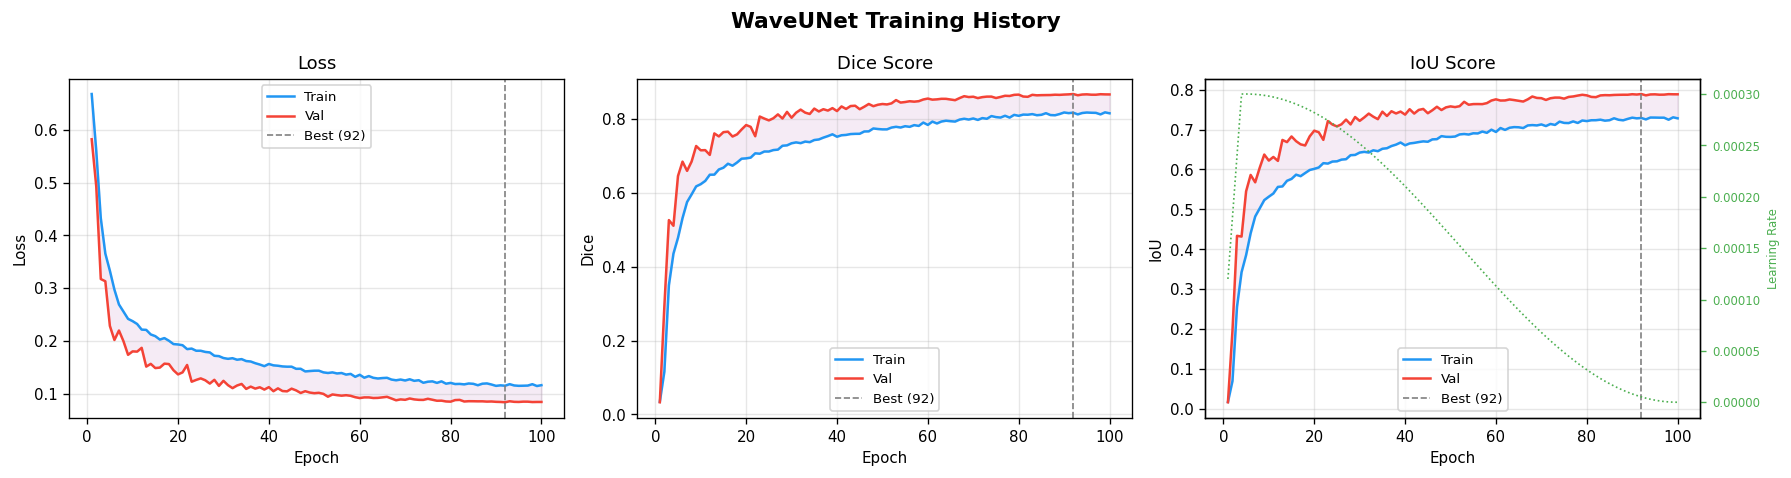

In [16]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('WaveUNet Training History', fontsize=13, fontweight='bold')

palette = {'train': '#2196F3', 'val': '#F44336'}

for ax, (tr_key, va_key, title, ylabel) in zip(axes, [
    ('train_loss', 'val_loss', 'Loss',       'Loss'),
    ('train_dice', 'val_dice', 'Dice Score', 'Dice'),
    ('train_iou',  'val_iou',  'IoU Score',  'IoU'),]):
    
    ax.plot(epochs, history[tr_key], label='Train', color=palette['train'], lw=1.5)
    ax.plot(epochs, history[va_key], label='Val',   color=palette['val'],   lw=1.5)
    ax.axvline(best_epoch, ls='--', color='gray', lw=1, label=f'Best ({best_epoch})')
    ax.fill_between(epochs, history[tr_key], history[va_key],alpha=0.08, color='purple')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

ax2b = axes[2].twinx()
ax2b.plot(epochs, history['lr'], color='#4CAF50', lw=1, ls='dotted', label='LR')
ax2b.set_ylabel('Learning Rate', color='#4CAF50', fontsize=7)
ax2b.tick_params(axis='y', colors='#4CAF50', labelsize=7)

plt.tight_layout()
plt.savefig('/kaggle/working/waveunet_history.png', bbox_inches='tight')
plt.show()

In [ ]:
@torch.no_grad()
def evaluate_metrics(model, loader, device=CFG.DEVICE, threshold=0.5):
    model.eval()
    records = []
    for imgs, masks in loader:
        logits = model(imgs.to(device))
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > threshold).astype(np.uint8)
        gts = masks.numpy().astype(np.uint8)
        for pred, gt in zip(preds, gts):
            p, t = pred[0], gt[0]
            tp = int((p & t).sum())
            tn = int(((1-p)&(1-t)).sum())
            fp = int((p & (1-t)).sum())
            fn = int(((1-p)&t).sum())
            records.append(dict(
                dice = (2*tp+1e-6)/(2*tp+fp+fn+1e-6),
                iou = (tp+1e-6)/(tp+fp+fn+1e-6),
                precision = (tp+1e-6)/(tp+fp+1e-6),
                recall = (tp+1e-6)/(tp+fn+1e-6),
                specificity = (tn+1e-6)/(tn+fp+1e-6),
                hd95 = compute_hd95(p,t) if p.sum()>0 and t.sum()>0 else np.nan,))
            
    return records

print('Evaluating splits')
tr_records = evaluate_metrics(model, train_loader)
va_records = evaluate_metrics(model, val_loader)
te_records = evaluate_metrics(model, test_loader)

def make_summary(records, label):
    df = pd.DataFrame(records)
    row = {'Split': label}
    for col in df.columns:
        v = df[col].dropna()
        row[col.capitalize()] = f'{v.mean():.4f} ± {v.std():.4f}'
    return row

summary_df = pd.DataFrame([make_summary(tr_records, 'Train'),make_summary(va_records, 'Val'),make_summary(te_records, 'Test'),]).set_index('Split')

print('\nMetric Summary\n')
print(summary_df.to_string())

Evaluating splits

Metric Summary

                  Dice              Iou        Precision           Recall      Specificity              Hd95
Split                                                                                                       
Train  0.8138 ± 0.2172  0.7270 ± 0.2280  0.8417 ± 0.2087  0.8290 ± 0.2229  0.9978 ± 0.0038  9.8125 ± 16.9752
Val    0.8674 ± 0.1543  0.7892 ± 0.1758  0.8852 ± 0.1592  0.8760 ± 0.1652  0.9983 ± 0.0034  7.7903 ± 14.6930
Test   0.8600 ± 0.1724  0.7835 ± 0.1966  0.8713 ± 0.1776  0.8796 ± 0.1741  0.9983 ± 0.0031  7.1821 ± 13.2333


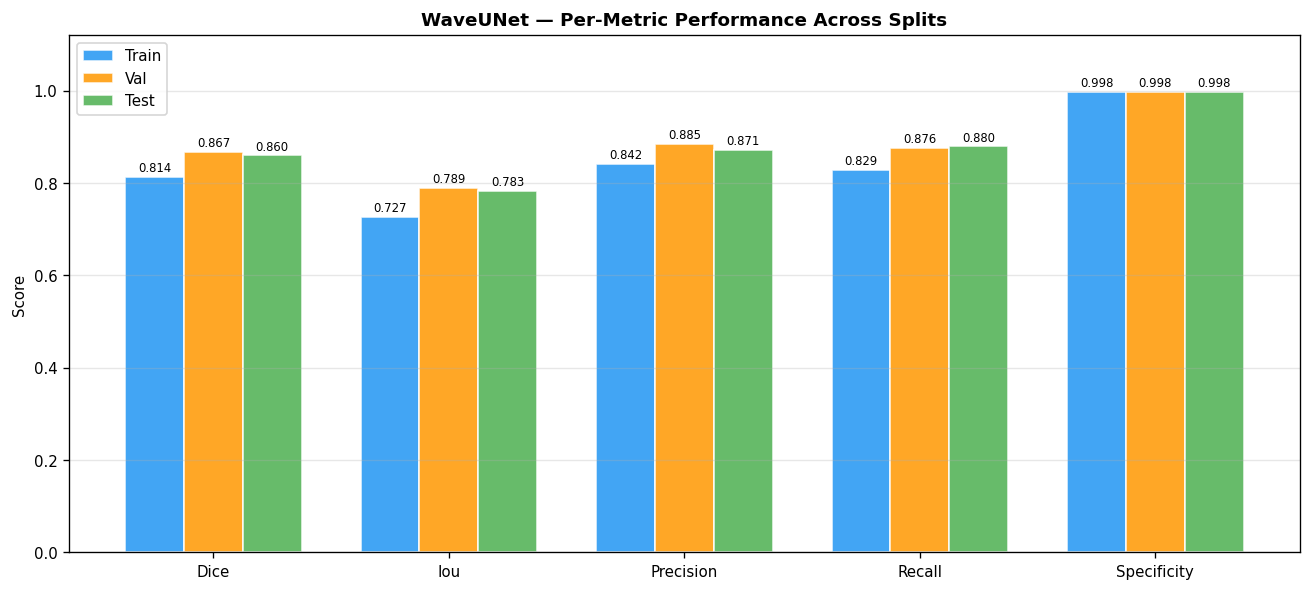

In [ ]:
metrics = ['Dice','Iou','Precision','Recall','Specificity']
splits = ['Train','Val','Test']
records_map = {'Train': tr_records, 'Val': va_records, 'Test': te_records}

means = {s: [pd.DataFrame(records_map[s])[m.lower()].mean() for m in metrics] for s in splits}

x = np.arange(len(metrics))
w = 0.25
cols = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (split, col) in enumerate(zip(splits, cols)):
    bars = ax.bar(x + i*w, means[split], w, label=split, color=col, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, means[split]):
        ax.text(bar.get_x() + bar.get_width()/2,bar.get_height() + 0.005,f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + w)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('WaveUNet — Per-Metric Performance Across Splits',fontsize=11, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/metric_bars.png', bbox_inches='tight')
plt.show()

## Visualizations 

In [ ]:
@torch.no_grad()
def get_predictions(loader, model, n=6, device=CFG.DEVICE):
    samples = []
    for imgs, masks in loader:
        logits = model(imgs.to(device))
        preds = (torch.sigmoid(logits) > 0.5).cpu().numpy().astype(np.float32)
        imgs_np = imgs.numpy()
        masks_np = masks.numpy()
        for i in range(len(imgs_np)):
            d = float(dice_score(preds[i,0], masks_np[i,0]))
            samples.append({'image': imgs_np[i,0], 'gt': masks_np[i,0],
                            'pred': preds[i,0], 'dice': d})
        if len(samples) >= n: break
    return samples[:n]

In [37]:
all_test_samples = get_predictions(test_loader, model, n=len(test_ds))
all_test_samples.sort(key=lambda x: x['dice'])

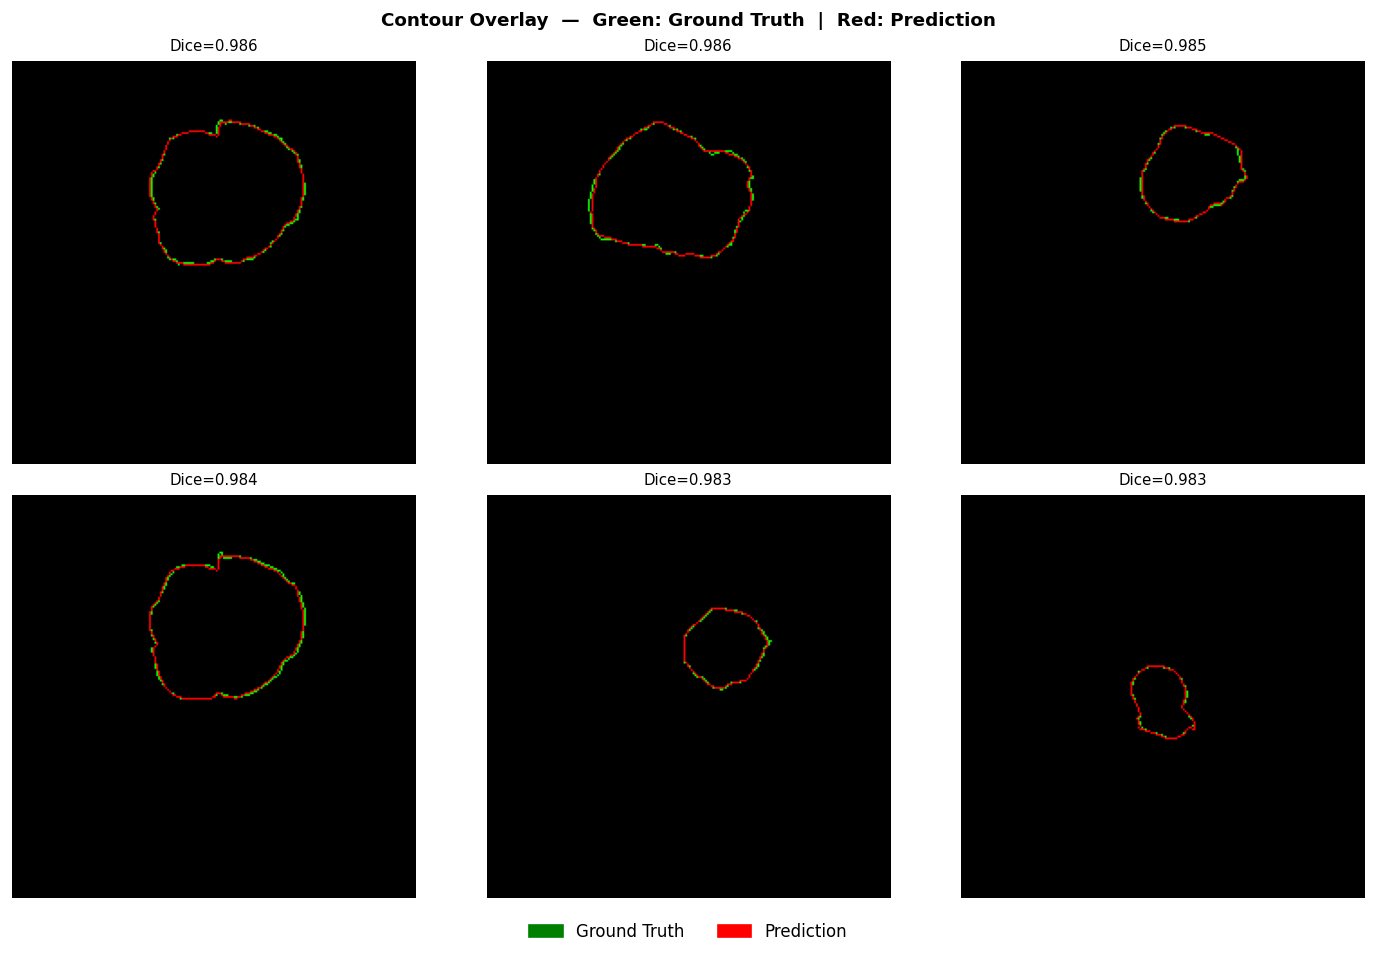

In [38]:
def draw_contour_overlay(img_gray, gt_mask, pred_mask):
    img_u8 = (img_gray * 255).clip(0,255).astype(np.uint8)
    rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    gt_u8 = (gt_mask   * 255).astype(np.uint8)
    pred_u8 = (pred_mask * 255).astype(np.uint8)
    gt_c,_ = cv2.findContours(gt_u8,   cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pr_c,_ = cv2.findContours(pred_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(rgb, gt_c, -1, (0,255,0), 1)
    cv2.drawContours(rgb, pr_c, -1, (0,0,255), 1)
    return cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

overlay_samples = sorted(all_test_samples, key=lambda x: x['dice'], reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Contour Overlay  —  Green: Ground Truth  |  Red: Prediction',fontsize=11, fontweight='bold')

for ax, s in zip(axes.flat, overlay_samples):
    ax.imshow(draw_contour_overlay(s['image'], s['gt'], s['pred']))
    ax.set_title(f'Dice={s["dice"]:.3f}', fontsize=9)
    ax.axis('off')

fig.legend(handles=[mpatches.Patch(color='green', label='Ground Truth'),
    mpatches.Patch(color='red',   label='Prediction'),], loc='lower center', ncol=2, fontsize=10, frameon=False)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('/kaggle/working/contour_overlay.png', bbox_inches='tight')
plt.show()

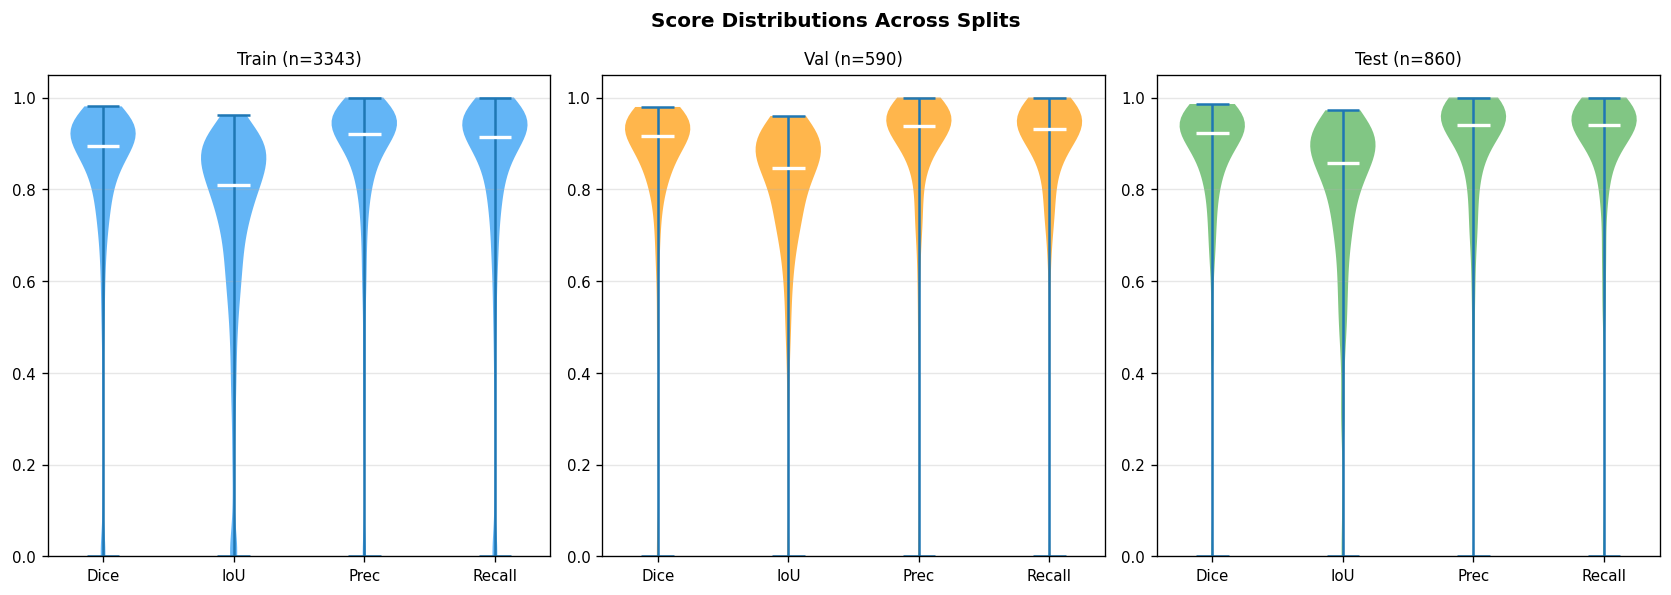

In [39]:
te_df = pd.DataFrame(te_records)
tr_df = pd.DataFrame(tr_records)
va_df = pd.DataFrame(va_records)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Score Distributions Across Splits', fontsize=12, fontweight='bold')

for ax, (df, label, col) in zip(axes, [
    (tr_df, 'Train', '#2196F3'),
    (va_df, 'Val',   '#FF9800'),
    (te_df, 'Test',  '#4CAF50'),]):
    
    data = [df['dice'].dropna().values,df['iou'].dropna().values,df['precision'].dropna().values,df['recall'].dropna().values]
    vp = ax.violinplot(data, positions=[1,2,3,4], showmedians=True)
    for body in vp['bodies']:
        body.set_facecolor(col); body.set_alpha(0.7)
    vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(2)
    ax.set_xticks([1,2,3,4])
    ax.set_xticklabels(['Dice','IoU','Prec','Recall'])
    ax.set_ylim(0, 1.05)
    ax.set_title(f'{label} (n={len(df)})', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/score_distributions.png', bbox_inches='tight')
plt.show()

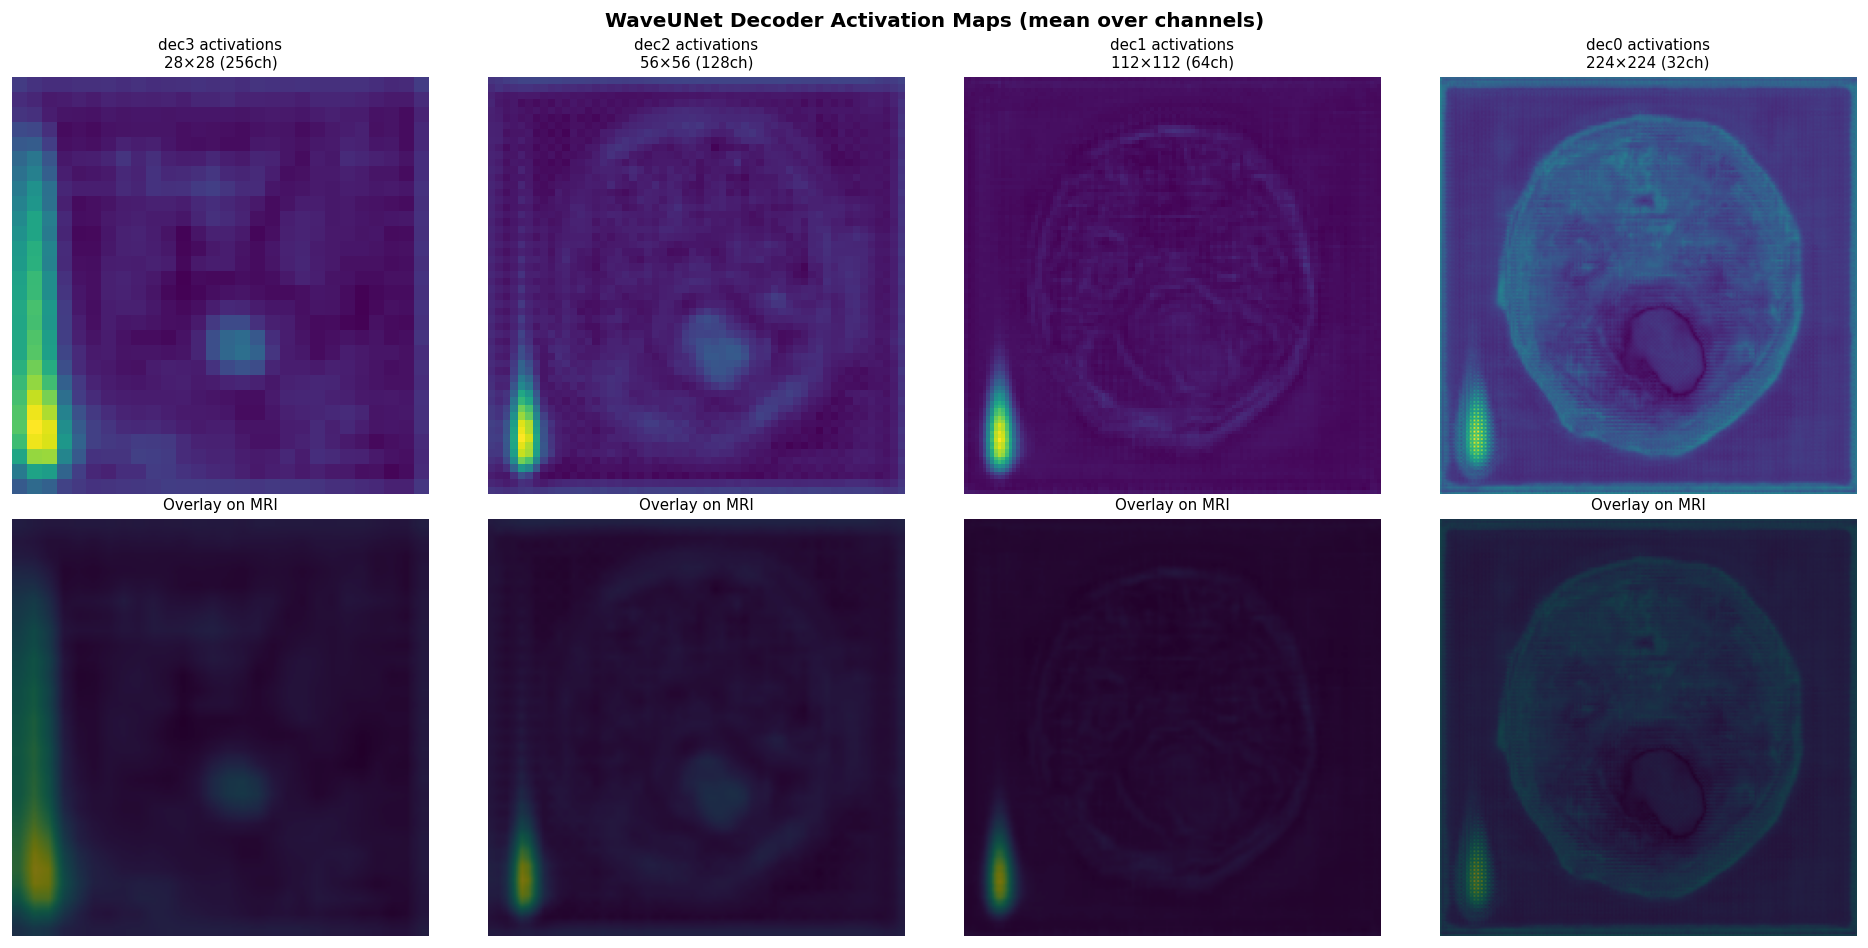

In [ ]:
activation_maps = {}

def _save_activation(name):
    def hook(module, inp, out):
        activation_maps[name] = out.detach().cpu()
    return hook

hooks = [model.dec3.conv.register_forward_hook(_save_activation('dec3')),
    model.dec2.conv.register_forward_hook(_save_activation('dec2')),
    model.dec1.conv.register_forward_hook(_save_activation('dec1')),
    model.dec0.conv.register_forward_hook(_save_activation('dec0')),]

imgs_batch, masks_batch = next(iter(test_loader))
with torch.no_grad():
    _ = model(imgs_batch.to(CFG.DEVICE))

for h in hooks: h.remove()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('WaveUNet Decoder Activation Maps (mean over channels)',fontsize=12, fontweight='bold')

sample_img = imgs_batch[0, 0].numpy()

for col, (level, ax_top, ax_bot) in enumerate(zip(['dec3','dec2','dec1','dec0'], axes[0], axes[1])):
    act = activation_maps[level][0]
    act_mean = act.mean(0).numpy()
    act_mean = (act_mean - act_mean.min()) / (act_mean.max() - act_mean.min() + 1e-8)

    act_up = cv2.resize(act_mean, (224, 224), interpolation=cv2.INTER_LINEAR)
    img_u8 = (sample_img * 255).astype(np.uint8)
    heat = cv2.applyColorMap((act_up*255).astype(np.uint8), cv2.COLORMAP_VIRIDIS)
    blend = cv2.cvtColor(cv2.addWeighted(cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR), 0.5, heat, 0.5, 0),cv2.COLOR_BGR2RGB)

    sizes = {0: '28×28', 1: '56×56', 2: '112×112', 3: '224×224'}
    ax_top.imshow(act_mean, cmap='viridis')
    ax_top.set_title(f'{level} activations\n{sizes[col]} ({act.shape[0]}ch)', fontsize=9)
    ax_top.axis('off')
    ax_bot.imshow(blend)
    ax_bot.set_title('Overlay on MRI', fontsize=9)
    ax_bot.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/wavelet_activations.png', bbox_inches='tight')
plt.show()


In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None; self.gradients = None
        target_layer.register_forward_hook(
            lambda m,i,o: setattr(self,'activations',o.detach()))
        target_layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self,'gradients',go[0].detach()))

    @torch.enable_grad()
    def __call__(self, img_tensor):
        self.model.eval()
        img_tensor = img_tensor.to(CFG.DEVICE).requires_grad_(True)
        logits = self.model(img_tensor)
        self.model.zero_grad()
        torch.sigmoid(logits).mean().backward()
        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=img_tensor.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 1e-8: cam /= cam.max()
        return cam

grad_cam = GradCAM(model, model.bottleneck.block[-3]) 

test_samples_gc = []
for imgs, masks in test_loader:
    logits = model(imgs.to(CFG.DEVICE))
    preds = (torch.sigmoid(logits) > 0.5).cpu().numpy().astype(np.float32)
    for i in range(len(imgs)):
        d = float(((2*(preds[i,0]*masks[i,0].numpy()).sum()+1e-6) / (preds[i,0].sum()+masks[i,0].numpy().sum()+1e-6)))
        test_samples_gc.append({'image': imgs[i,0].numpy(), 'pred': preds[i,0], 'dice': d})
    if len(test_samples_gc) >= 4: break
test_samples_gc = test_samples_gc[:4]

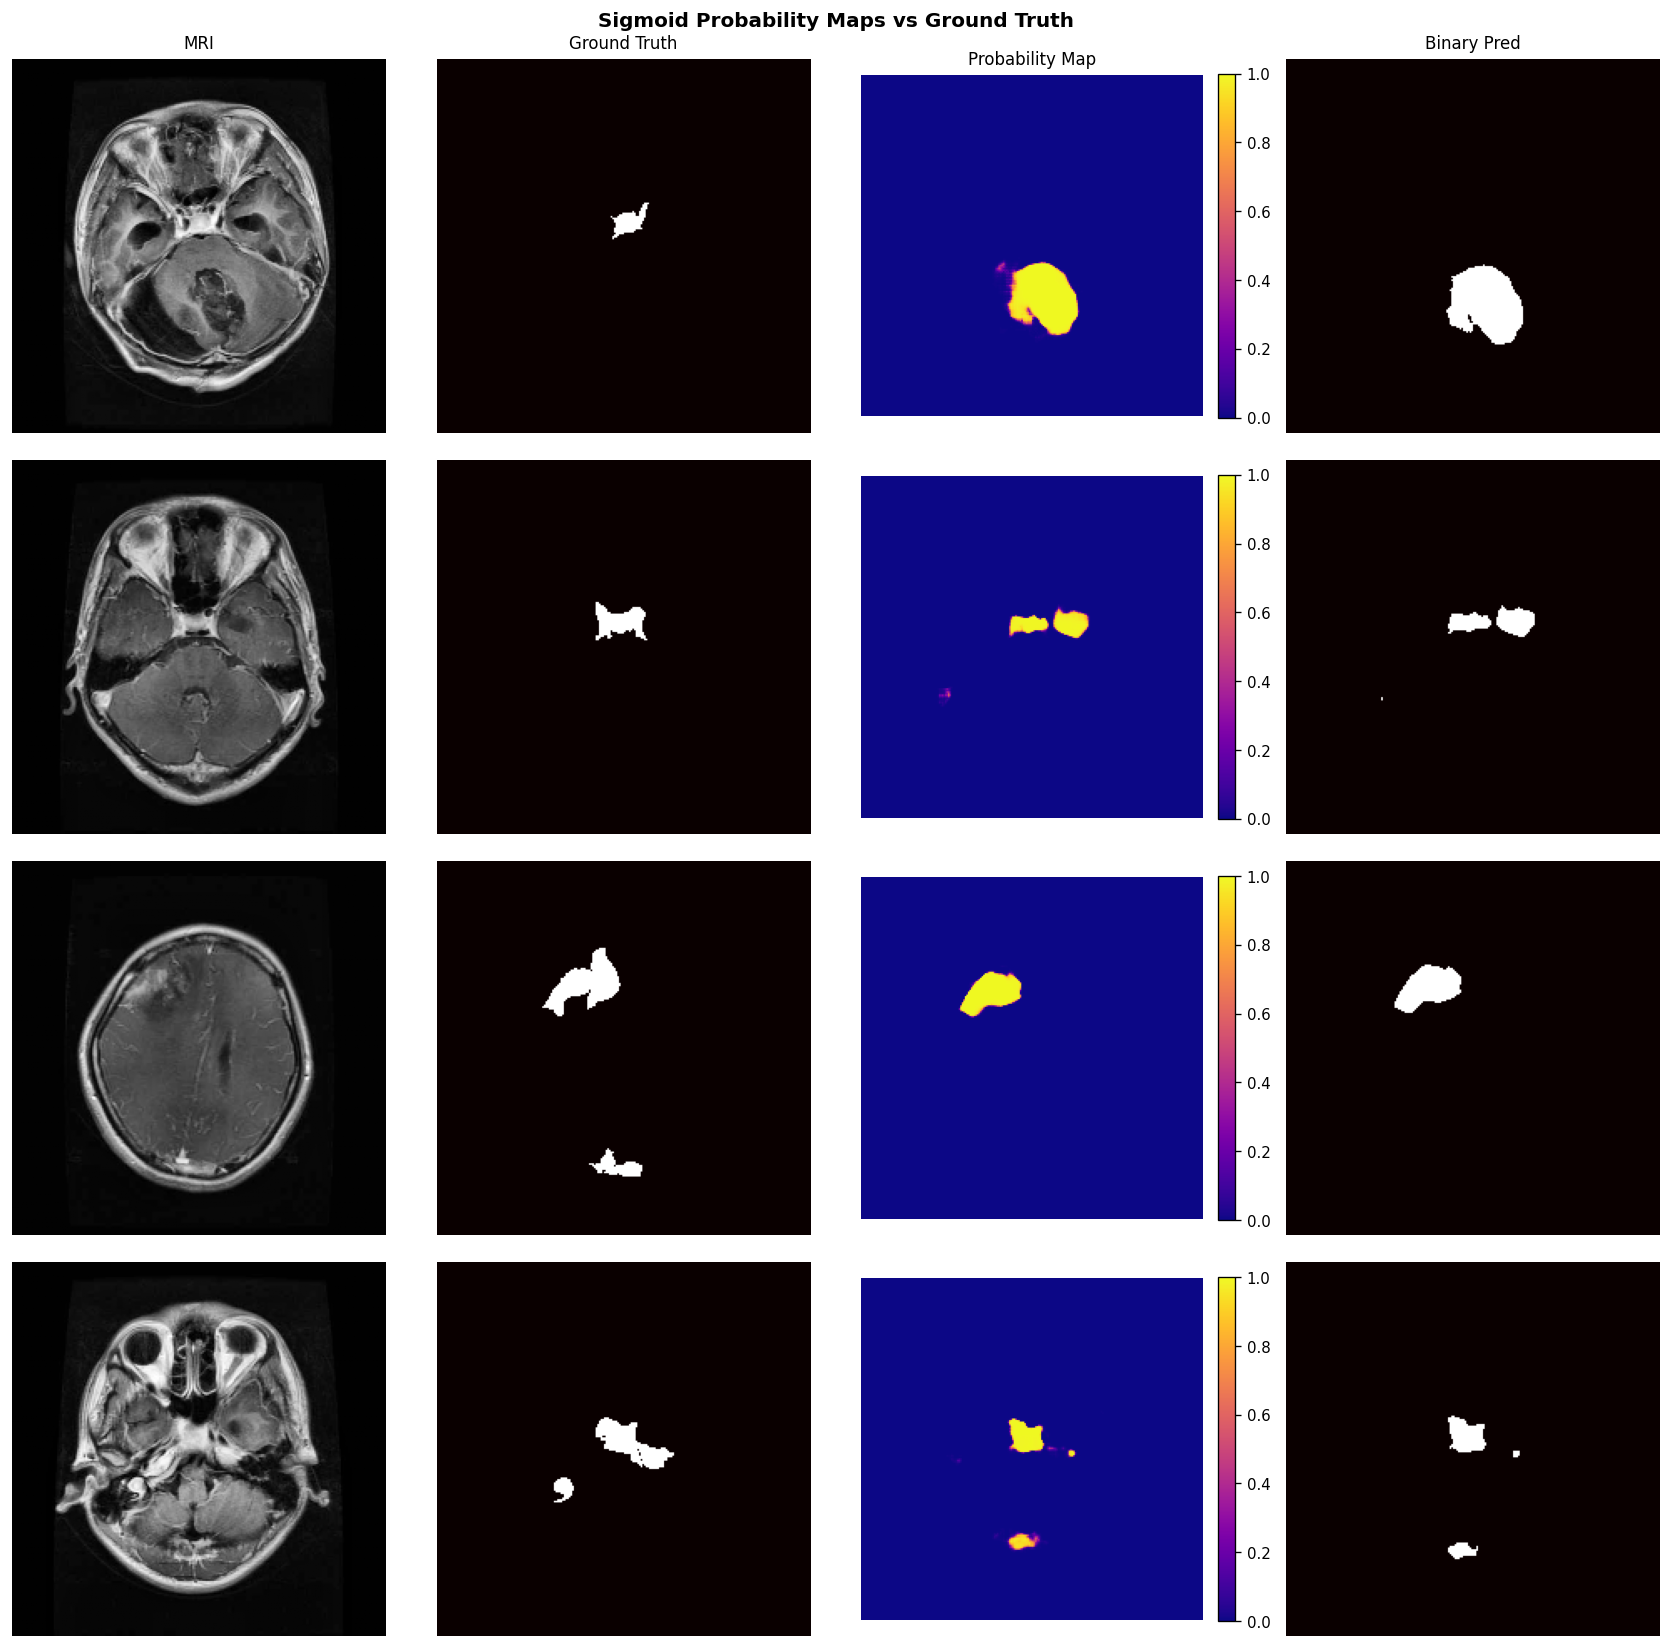

In [ ]:
prob_samples = get_predictions(test_loader, model, n=4)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Sigmoid Probability Maps vs Ground Truth', fontsize=12, fontweight='bold')

for col_title, col in zip(['MRI','Ground Truth','Probability Map','Binary Pred'], range(4)):
    axes[0, col].set_title(col_title, fontsize=10)

@torch.no_grad()
def get_prob_maps(loader, model, n=4, device=CFG.DEVICE):
    results = []
    for imgs, masks in loader:
        logits = model(imgs.to(device))
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(np.float32)
        for i in range(len(imgs)):
            results.append({'image': imgs[i,0].numpy(),'gt':    masks[i,0].numpy(),'prob':  probs[i,0],'pred':  preds[i,0],})
        if len(results) >= n: break
    return results[:n]

prob_results = get_prob_maps(test_loader, model, n=4)

for row, r in enumerate(prob_results):
    axes[row,0].imshow(r['image'], cmap='gray')
    axes[row,1].imshow(r['gt'], cmap='hot')
    im = axes[row,2].imshow(r['prob'], cmap='plasma', vmin=0, vmax=1)
    axes[row,3].imshow(r['pred'], cmap='hot')
    plt.colorbar(im, ax=axes[row,2], fraction=0.046, pad=0.04)
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/probability_maps.png', bbox_inches='tight')
plt.show()

In [ ]:
from scipy.ndimage import binary_erosion
import random as _random

def get_boundary(binary_mask, thickness=2):
    eroded = binary_erosion(binary_mask.astype(bool), iterations=thickness)
    return binary_mask.astype(bool) & ~eroded

def build_boundary_overlay(img, gt_mask, pred_mask):
    gt_b = get_boundary(gt_mask.astype(bool))
    pred_b = get_boundary(pred_mask.astype(bool))
    both = gt_b & pred_b

    rgb = np.stack([img, img, img], axis=-1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    rgb[gt_b, 0] = 0.0; rgb[gt_b,1] = 1.0; rgb[gt_b, 2] = 0.0
    rgb[pred_b, 0] = 1.0; rgb[pred_b, 1] = 0.0; rgb[pred_b, 2] = 0.0
    rgb[both, 0] = 1.0; rgb[both,1] = 1.0; rgb[both, 2] = 0.0
    return rgb

def iou_from_masks(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    inter = (gt & pred).sum()
    union = (gt | pred).sum()
    return (inter / union * 100) if union > 0 else 0.0

def plot_5_grid(samples_list, title, fname):
    n = len(samples_list)
    fig, axes = plt.subplots(n, 4, figsize=(13, 3.6 * n))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    for col, t in enumerate(['Input MRI', 'Ground Truth', 'Predicted Mask', 'Boundary Overlap']):
        axes[0][col].set_title(t, fontsize=11, fontweight='bold')

    for row, s in enumerate(samples_list):
        img = s['image']
        gt = s['gt'].astype(bool)
        pred = s['pred'].astype(bool)
        ovl = build_boundary_overlay(img, gt, pred)
        iou = iou_from_masks(gt, pred)

        axes[row][0].imshow(img,cmap='gray')
        axes[row][1].imshow(gt,cmap='gray')
        axes[row][2].imshow(pred,cmap='gray')
        axes[row][3].imshow(ovl)
        axes[row][3].text(0.98, 0.02, f'IoU: {iou:.1f}%',transform=axes[row][3].transAxes,fontsize=9, fontweight='bold', color='white',
                          ha='right', va='bottom',bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.6))
        axes[row][0].set_ylabel(f"Dice: {s['dice']:.4f}", fontsize=10)
        for col in range(4):
            axes[row][col].axis('off')

    legend = [mpatches.Patch(facecolor='green', label='GT boundary'),mpatches.Patch(facecolor='red',label='Pred boundary'),mpatches.Patch(facecolor='yellow', label='Intersection'),]
    fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=10,bbox_to_anchor=(0.75, -0.01), framealpha=0.8)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

print('Collecting all test-set predictions')
model.eval()
_all_samples = []
with torch.no_grad():
    for _imgs, _masks in test_loader:
        _logits = model(_imgs.to(CFG.DEVICE))
        _preds  = (torch.sigmoid(_logits) > 0.5).cpu().numpy().astype(np.float32)
        _imgs_np = _imgs.numpy()
        for _i in range(len(_imgs)):
            _p  = _preds[_i, 0]
            _m  = _masks[_i, 0].numpy()
            _d  = float((2*(_p*_m).sum() + 1e-6) / (_p.sum() + _m.sum() + 1e-6))
            _all_samples.append({'image':  _imgs_np[_i, 0],'img4':_imgs_np[_i],'gt':_m,'pred':_p,'dice':_d,})

_all_sorted = sorted(_all_samples, key=lambda x: x['dice'], reverse=True)
print(f'  Total test samples : {len(_all_samples)}')
print(f'  Best  Dice : {_all_sorted[0]["dice"]:.4f}')
print(f'  Worst Dice : {_all_sorted[-1]["dice"]:.4f}')


  Total test samples : 860
  Best  Dice : 0.9859
  Worst Dice : 0.0000


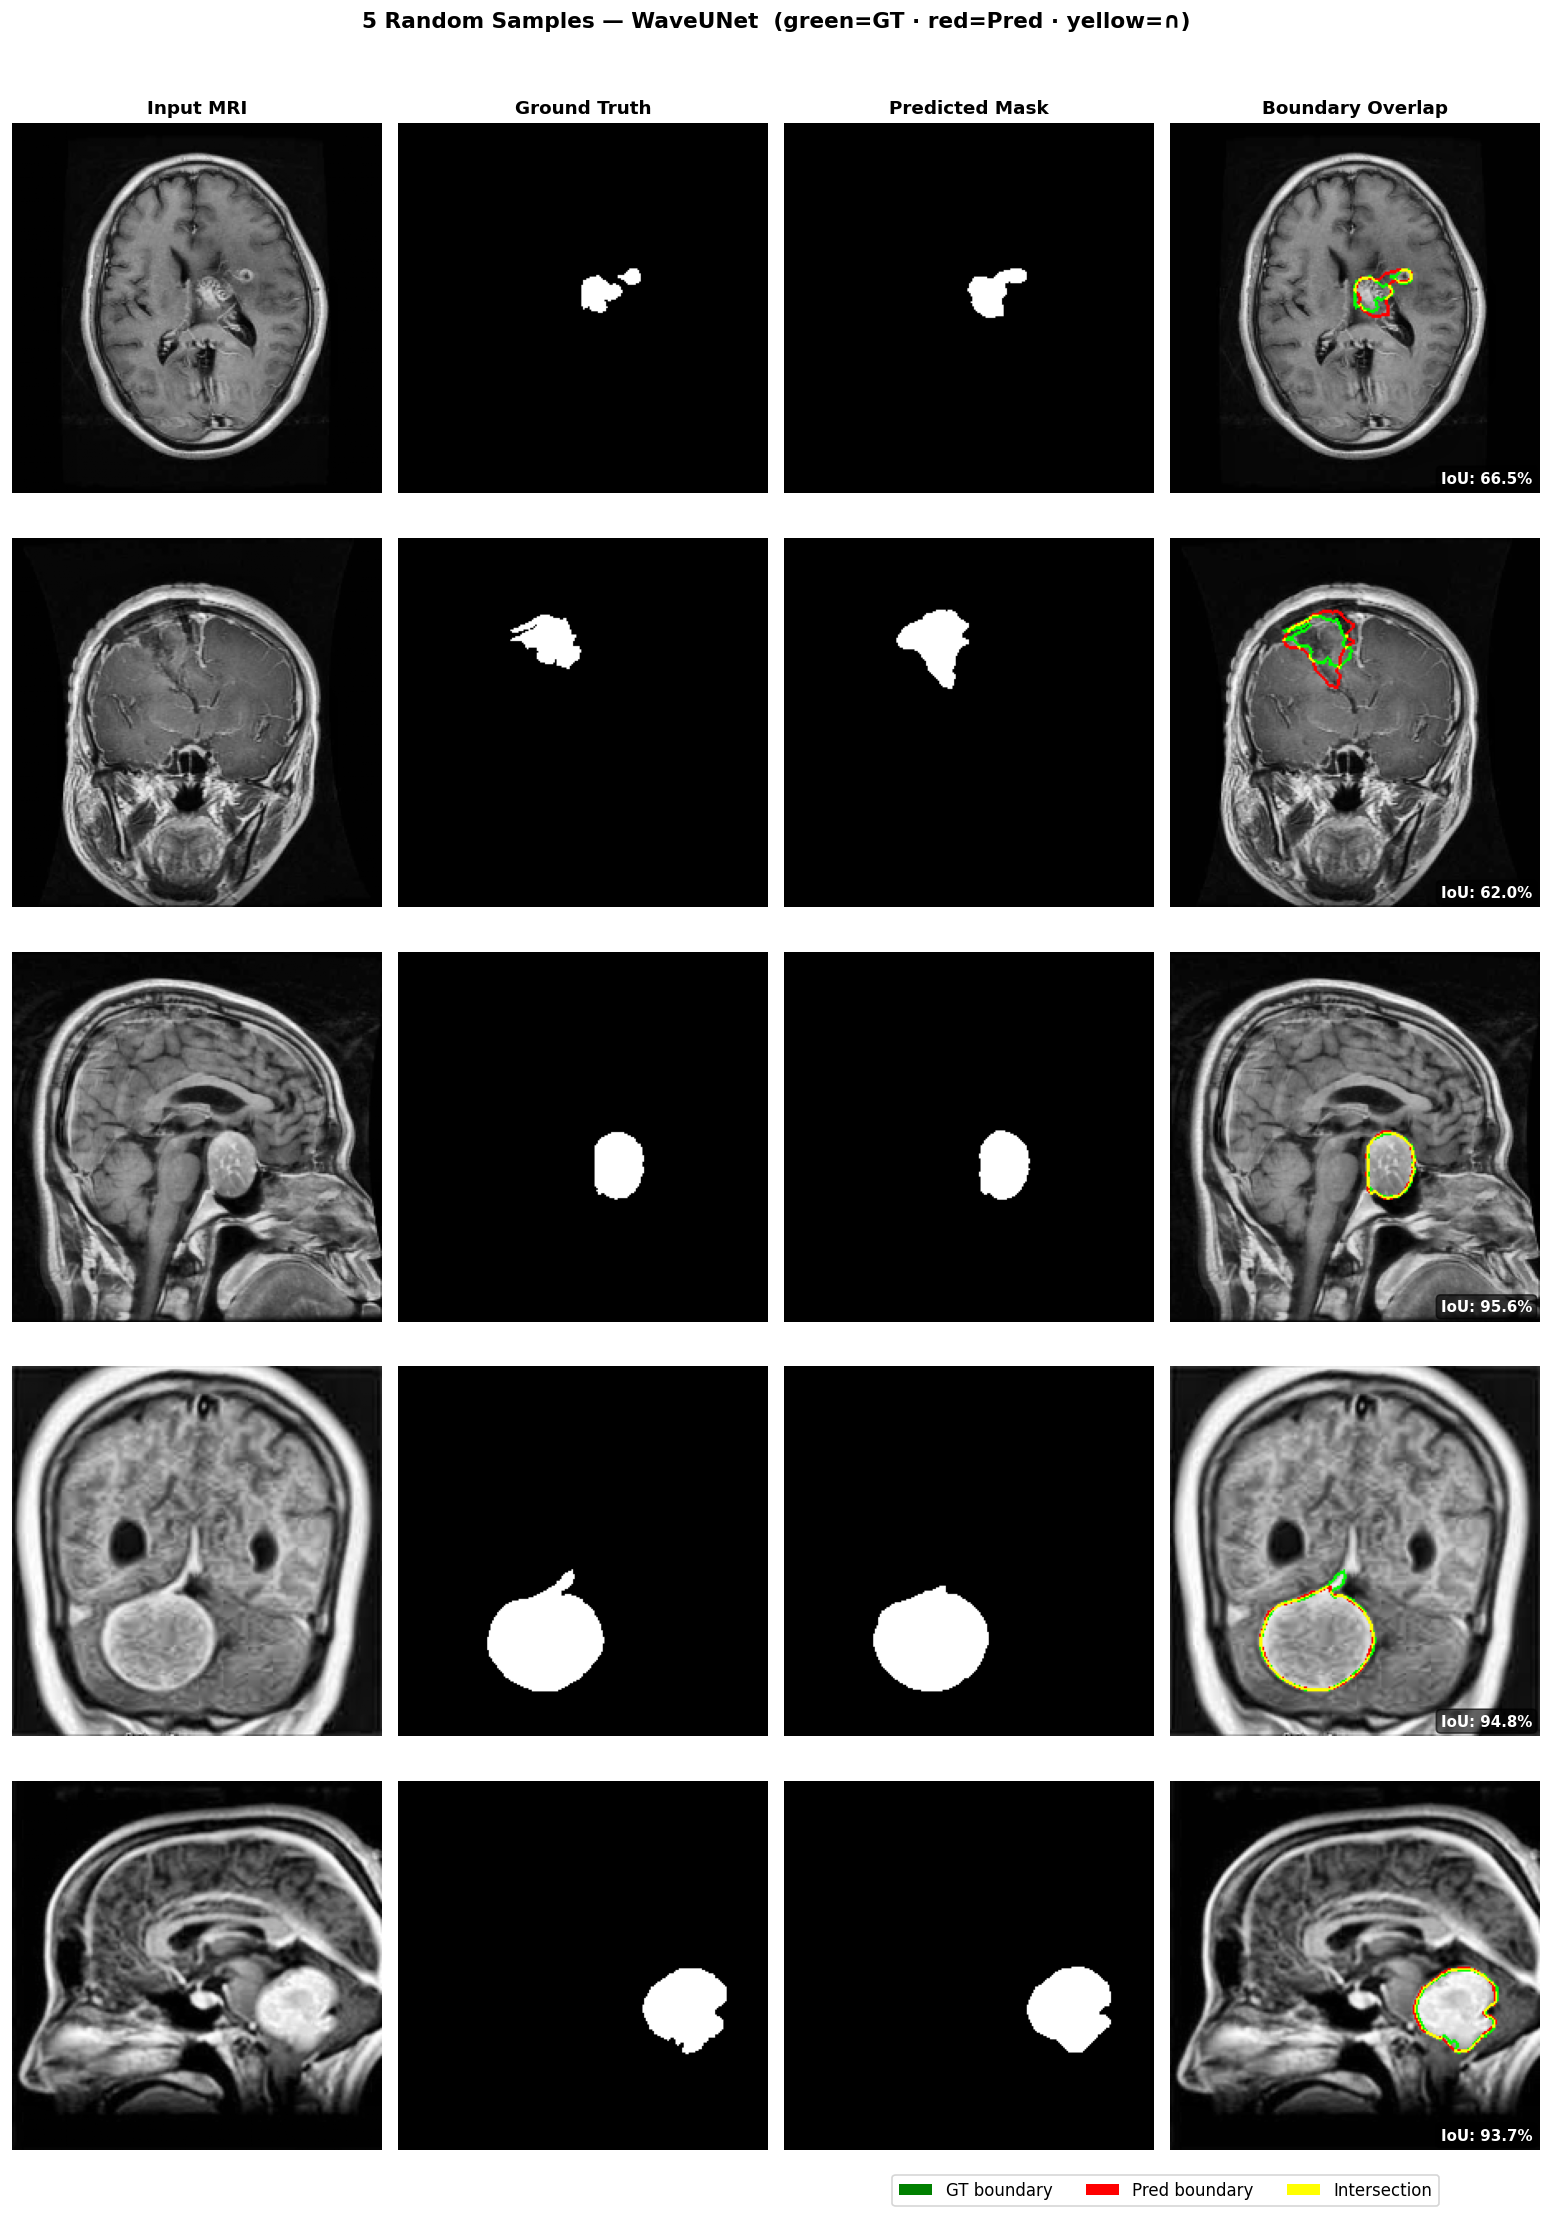

In [44]:
_random.seed(CFG.SEED)
random_5 = _random.sample(_all_samples, 5)
plot_5_grid(random_5,title='5 Random Samples — WaveUNet  (green=GT · red=Pred · yellow=∩)',fname='/kaggle/working/viz_random_5.png')


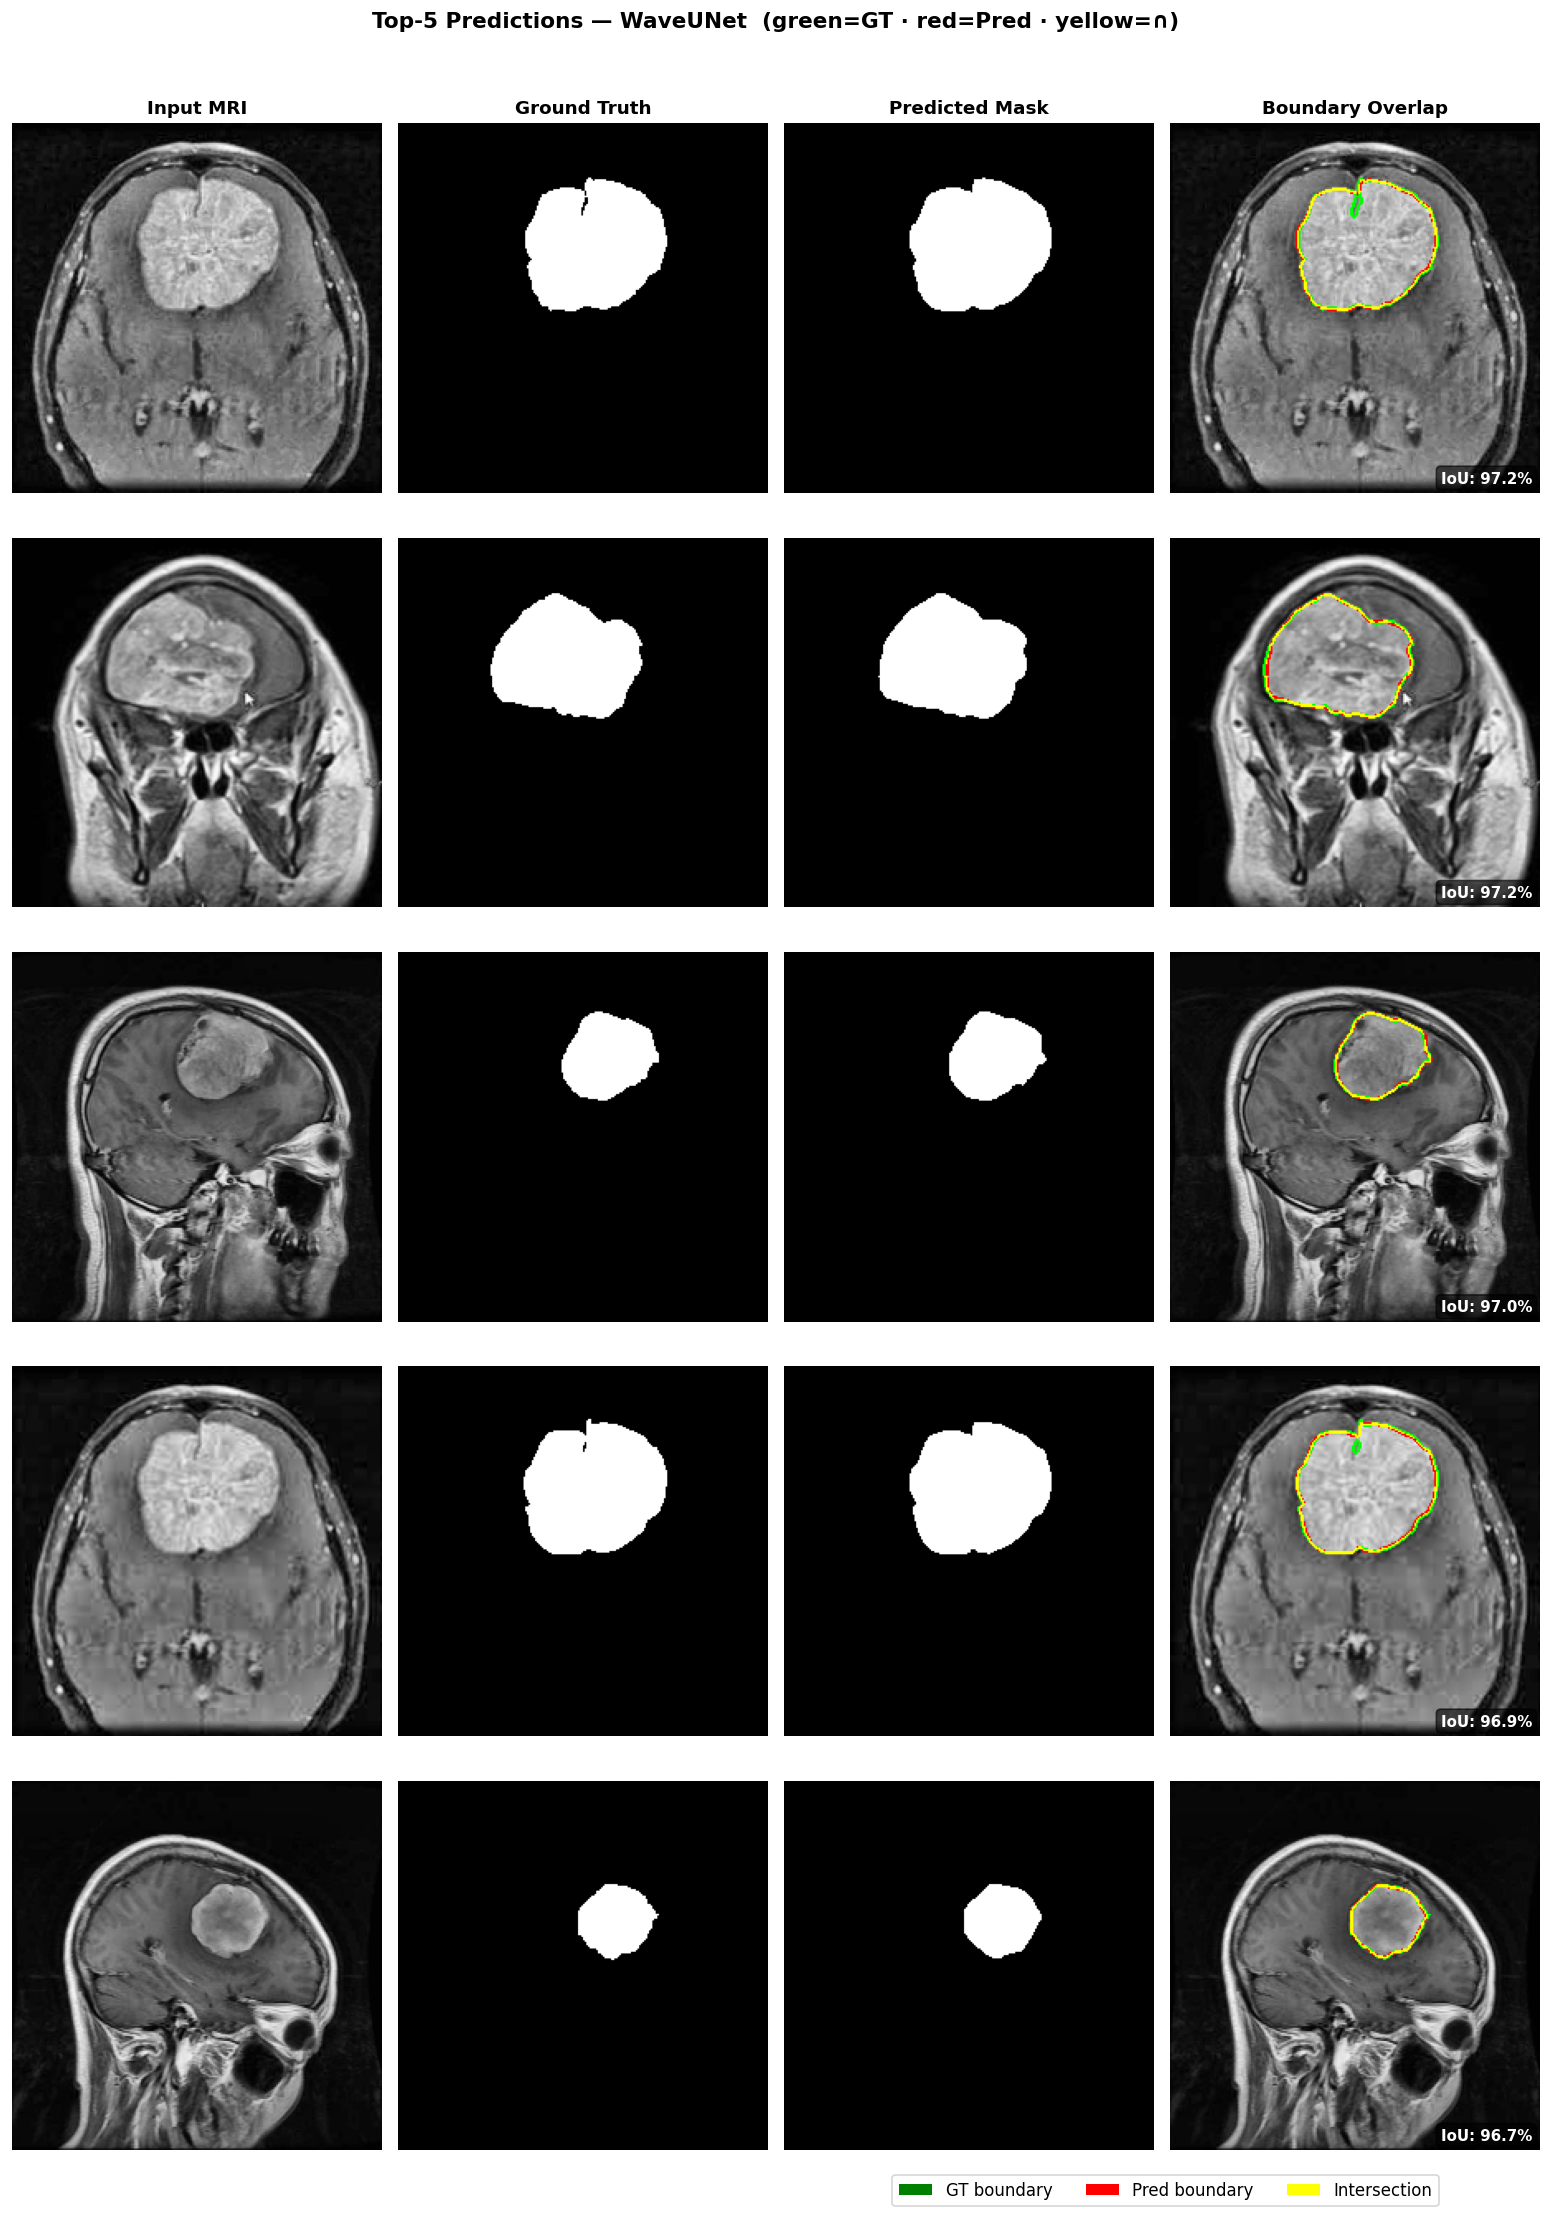

In [45]:
top_5 = _all_sorted[:5]
plot_5_grid(top_5,title='Top-5 Predictions — WaveUNet  (green=GT · red=Pred · yellow=∩)',fname='/kaggle/working/viz_top_5.png')

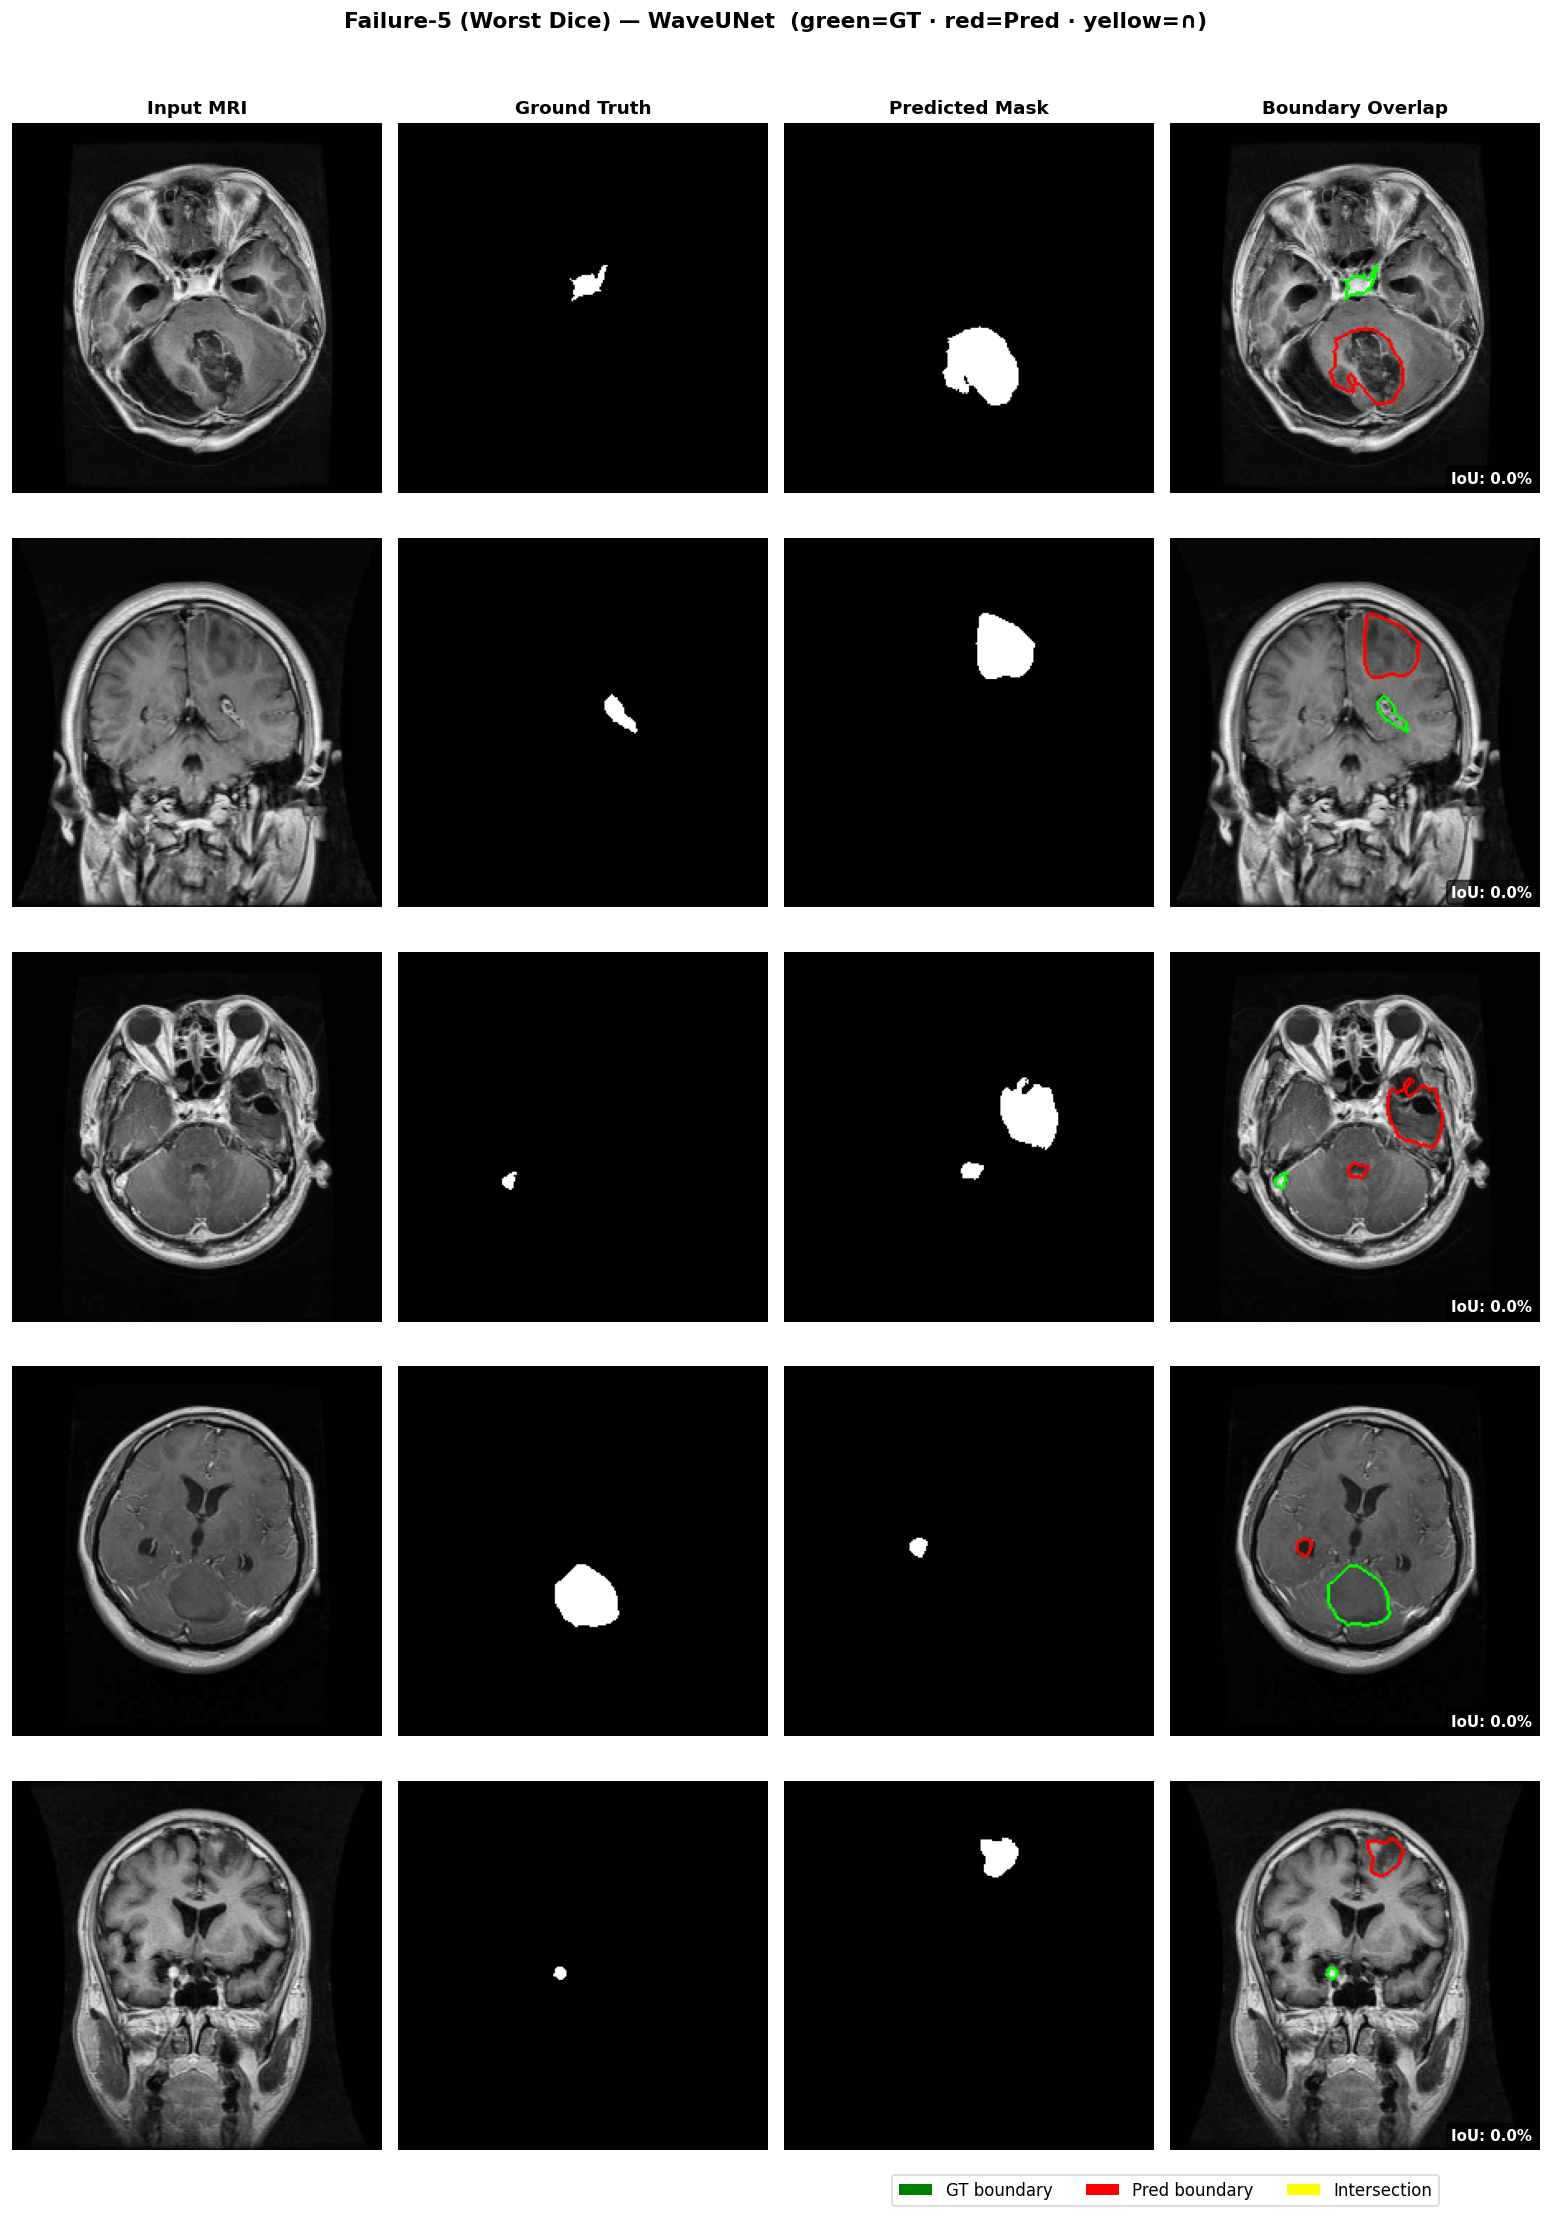

In [46]:
fail_5 = _all_sorted[-5:][::-1]
plot_5_grid(fail_5, title='Failure-5 (Worst Dice) — WaveUNet  (green=GT · red=Pred · yellow=∩)', fname='/kaggle/working/viz_failure_5.png')

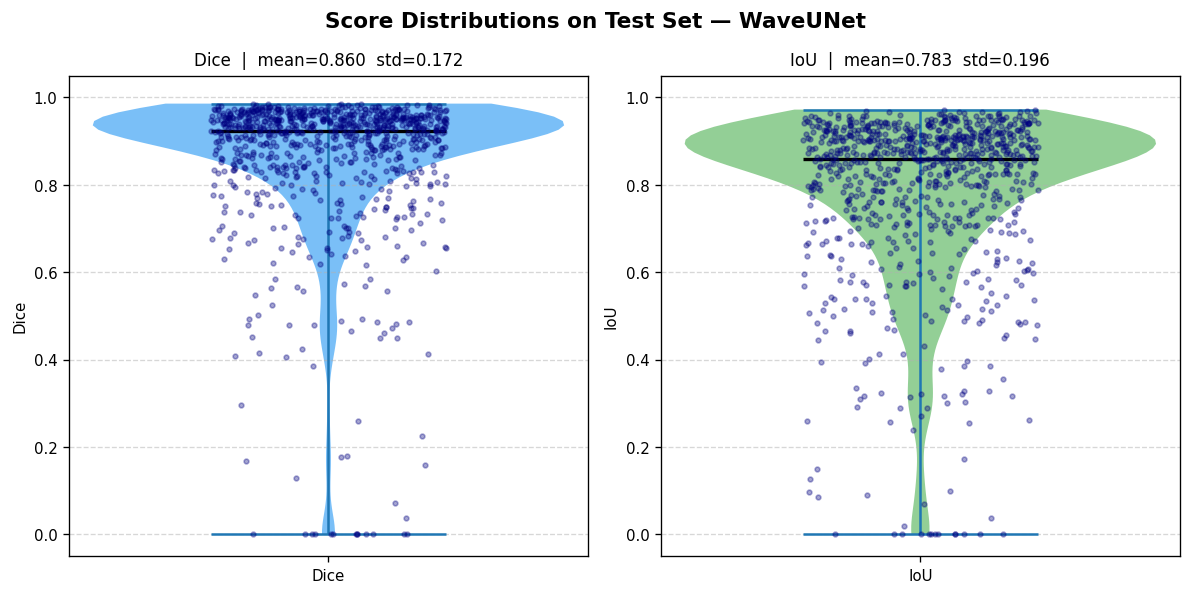

In [47]:
_violin_df = pd.DataFrame([{'Dice': s['dice'],'IoU' : iou_from_masks(s['gt'], s['pred']) / 100.0} for s in _all_samples ])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Score Distributions on Test Set — WaveUNet', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes, ['Dice', 'IoU'], ['#42A5F5', '#66BB6A']):
    vals = _violin_df[col].dropna().values
    parts = ax.violinplot(vals, positions=[0], showmedians=True, showextrema=True, widths=0.6)
    for pc in parts['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.7)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    jitter = np.random.uniform(-0.15, 0.15, len(vals))
    ax.scatter(jitter, vals, alpha=0.35, s=8, color='navy', zorder=3)
    ax.set_xticks([0]); ax.set_xticklabels([col])
    ax.set_ylabel(col)
    ax.set_title(f'{col}  |  mean={vals.mean():.3f}  std={vals.std():.3f}', fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/kaggle/working/viz_violin.png', dpi=150, bbox_inches='tight')
plt.show()

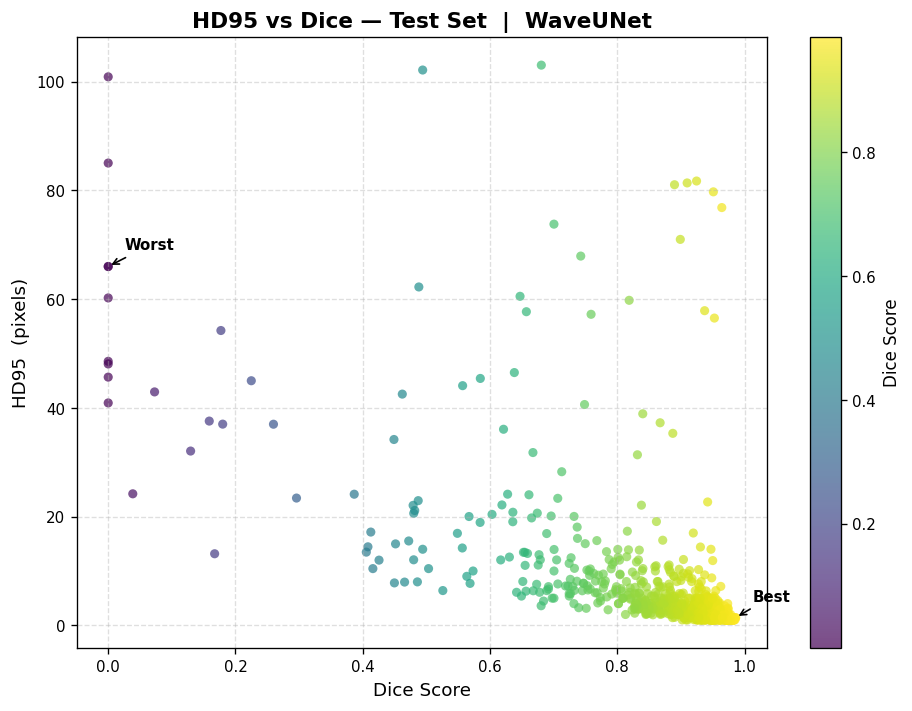

In [48]:
from medpy.metric.binary import hd95 as _hd95_fn

_scatter_records = []
for s in _all_samples:
    p = s['pred'].astype(np.uint8)
    t = s['gt'].astype(np.uint8)
    h = _hd95_fn(p, t) if (p.sum() > 0 and t.sum() > 0) else np.nan
    _scatter_records.append({'Dice': s['dice'], 'HD95': h})

sc_df = pd.DataFrame(_scatter_records).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(sc_df['Dice'], sc_df['HD95'], c=sc_df['Dice'], cmap='viridis', s=30, alpha=0.7, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Dice Score', fontsize=10)
ax.set_xlabel('Dice Score', fontsize=11)
ax.set_ylabel('HD95  (pixels)', fontsize=11)
ax.set_title('HD95 vs Dice — Test Set  |  WaveUNet', fontsize=13, fontweight='bold')
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

best_r  = sc_df.loc[sc_df['Dice'].idxmax()]
worst_r = sc_df.loc[sc_df['Dice'].idxmin()]
for r, lbl in [(best_r, 'Best'), (worst_r, 'Worst')]:
    ax.annotate(lbl, xy=(r['Dice'], r['HD95']), xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold', arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig('/kaggle/working/viz_hd95_dice_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

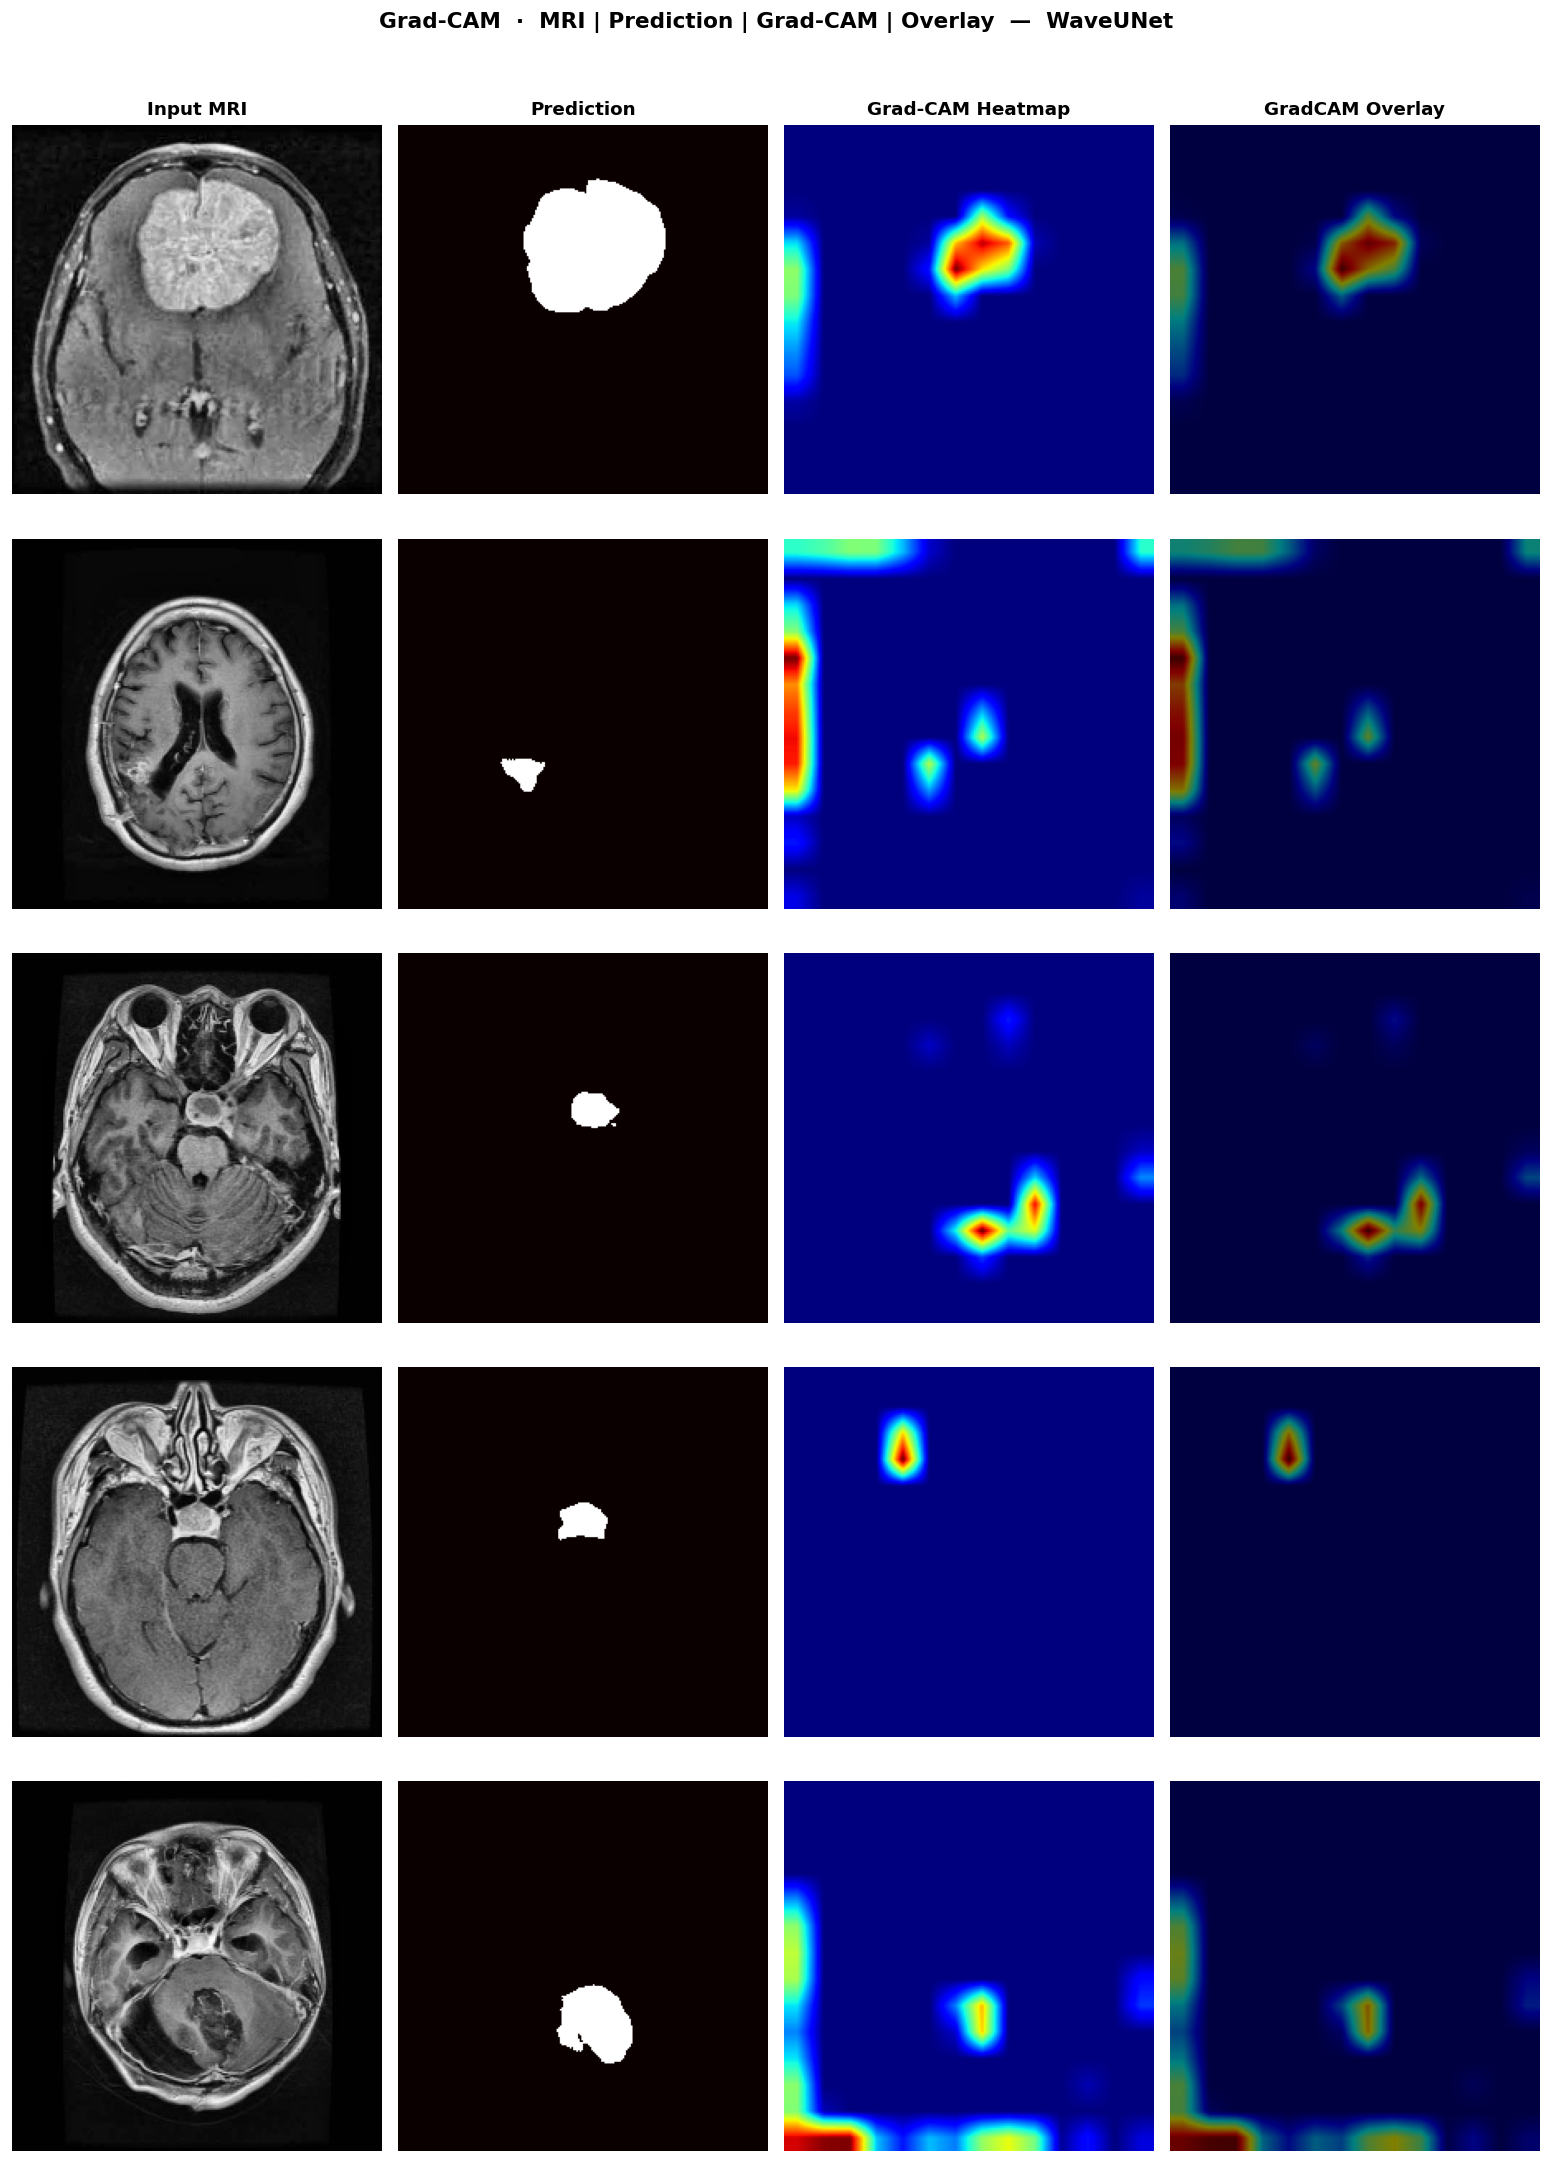

In [ ]:
_random.seed(CFG.SEED + 1)
_mid_gc = _all_sorted[1:-1]
_rand3_gc = _random.sample(_mid_gc, 3)
gradcam_5 = [_all_sorted[0]] + _rand3_gc + [_all_sorted[-1]]
labels_gc = ['Best'] + [f'Random {i+1}' for i in range(3)] + ['Worst']

fig, axes = plt.subplots(5, 4, figsize=(13, 3.6 * 5))
fig.suptitle('Grad-CAM  ·  MRI | Prediction | Grad-CAM | Overlay  —  WaveUNet',fontsize=13, fontweight='bold', y=1.01)

for col, t in enumerate(['Input MRI', 'Prediction', 'Grad-CAM Heatmap', 'GradCAM Overlay']):
    axes[0][col].set_title(t, fontsize=11, fontweight='bold')

for row, (s, lbl) in enumerate(zip(gradcam_5, labels_gc)):
    img_np = s['image']
    pred_np = s['pred']
    img4_np = s['img4']
    
    img_t = torch.from_numpy(img4_np).unsqueeze(0).float()
    heatmap = grad_cam(img_t)

    img_u8 = (img_np  * 255).clip(0, 255).astype(np.uint8)
    heat_u8 = (heatmap * 255).clip(0, 255).astype(np.uint8)
    heat_rgb = cv2.applyColorMap(heat_u8, cv2.COLORMAP_JET)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    overlay = cv2.addWeighted(img_rgb, 0.5, heat_rgb, 0.5, 0)
    overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(img_np,cmap='gray')
    axes[row][1].imshow(pred_np,cmap='hot')
    axes[row][2].imshow(heatmap,cmap='jet')
    axes[row][3].imshow(overlay)

    axes[row][0].set_ylabel(f'[{lbl}]\nDice={s["dice"]:.4f}', fontsize=9)
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_gradcam_5.png', dpi=150, bbox_inches='tight')
plt.show()

Computing occlusion maps
  [1/5] Best done
  [2/5] Random 1 done
  [3/5] Random 2 done
  [4/5] Random 3 done
  [5/5] Worst done


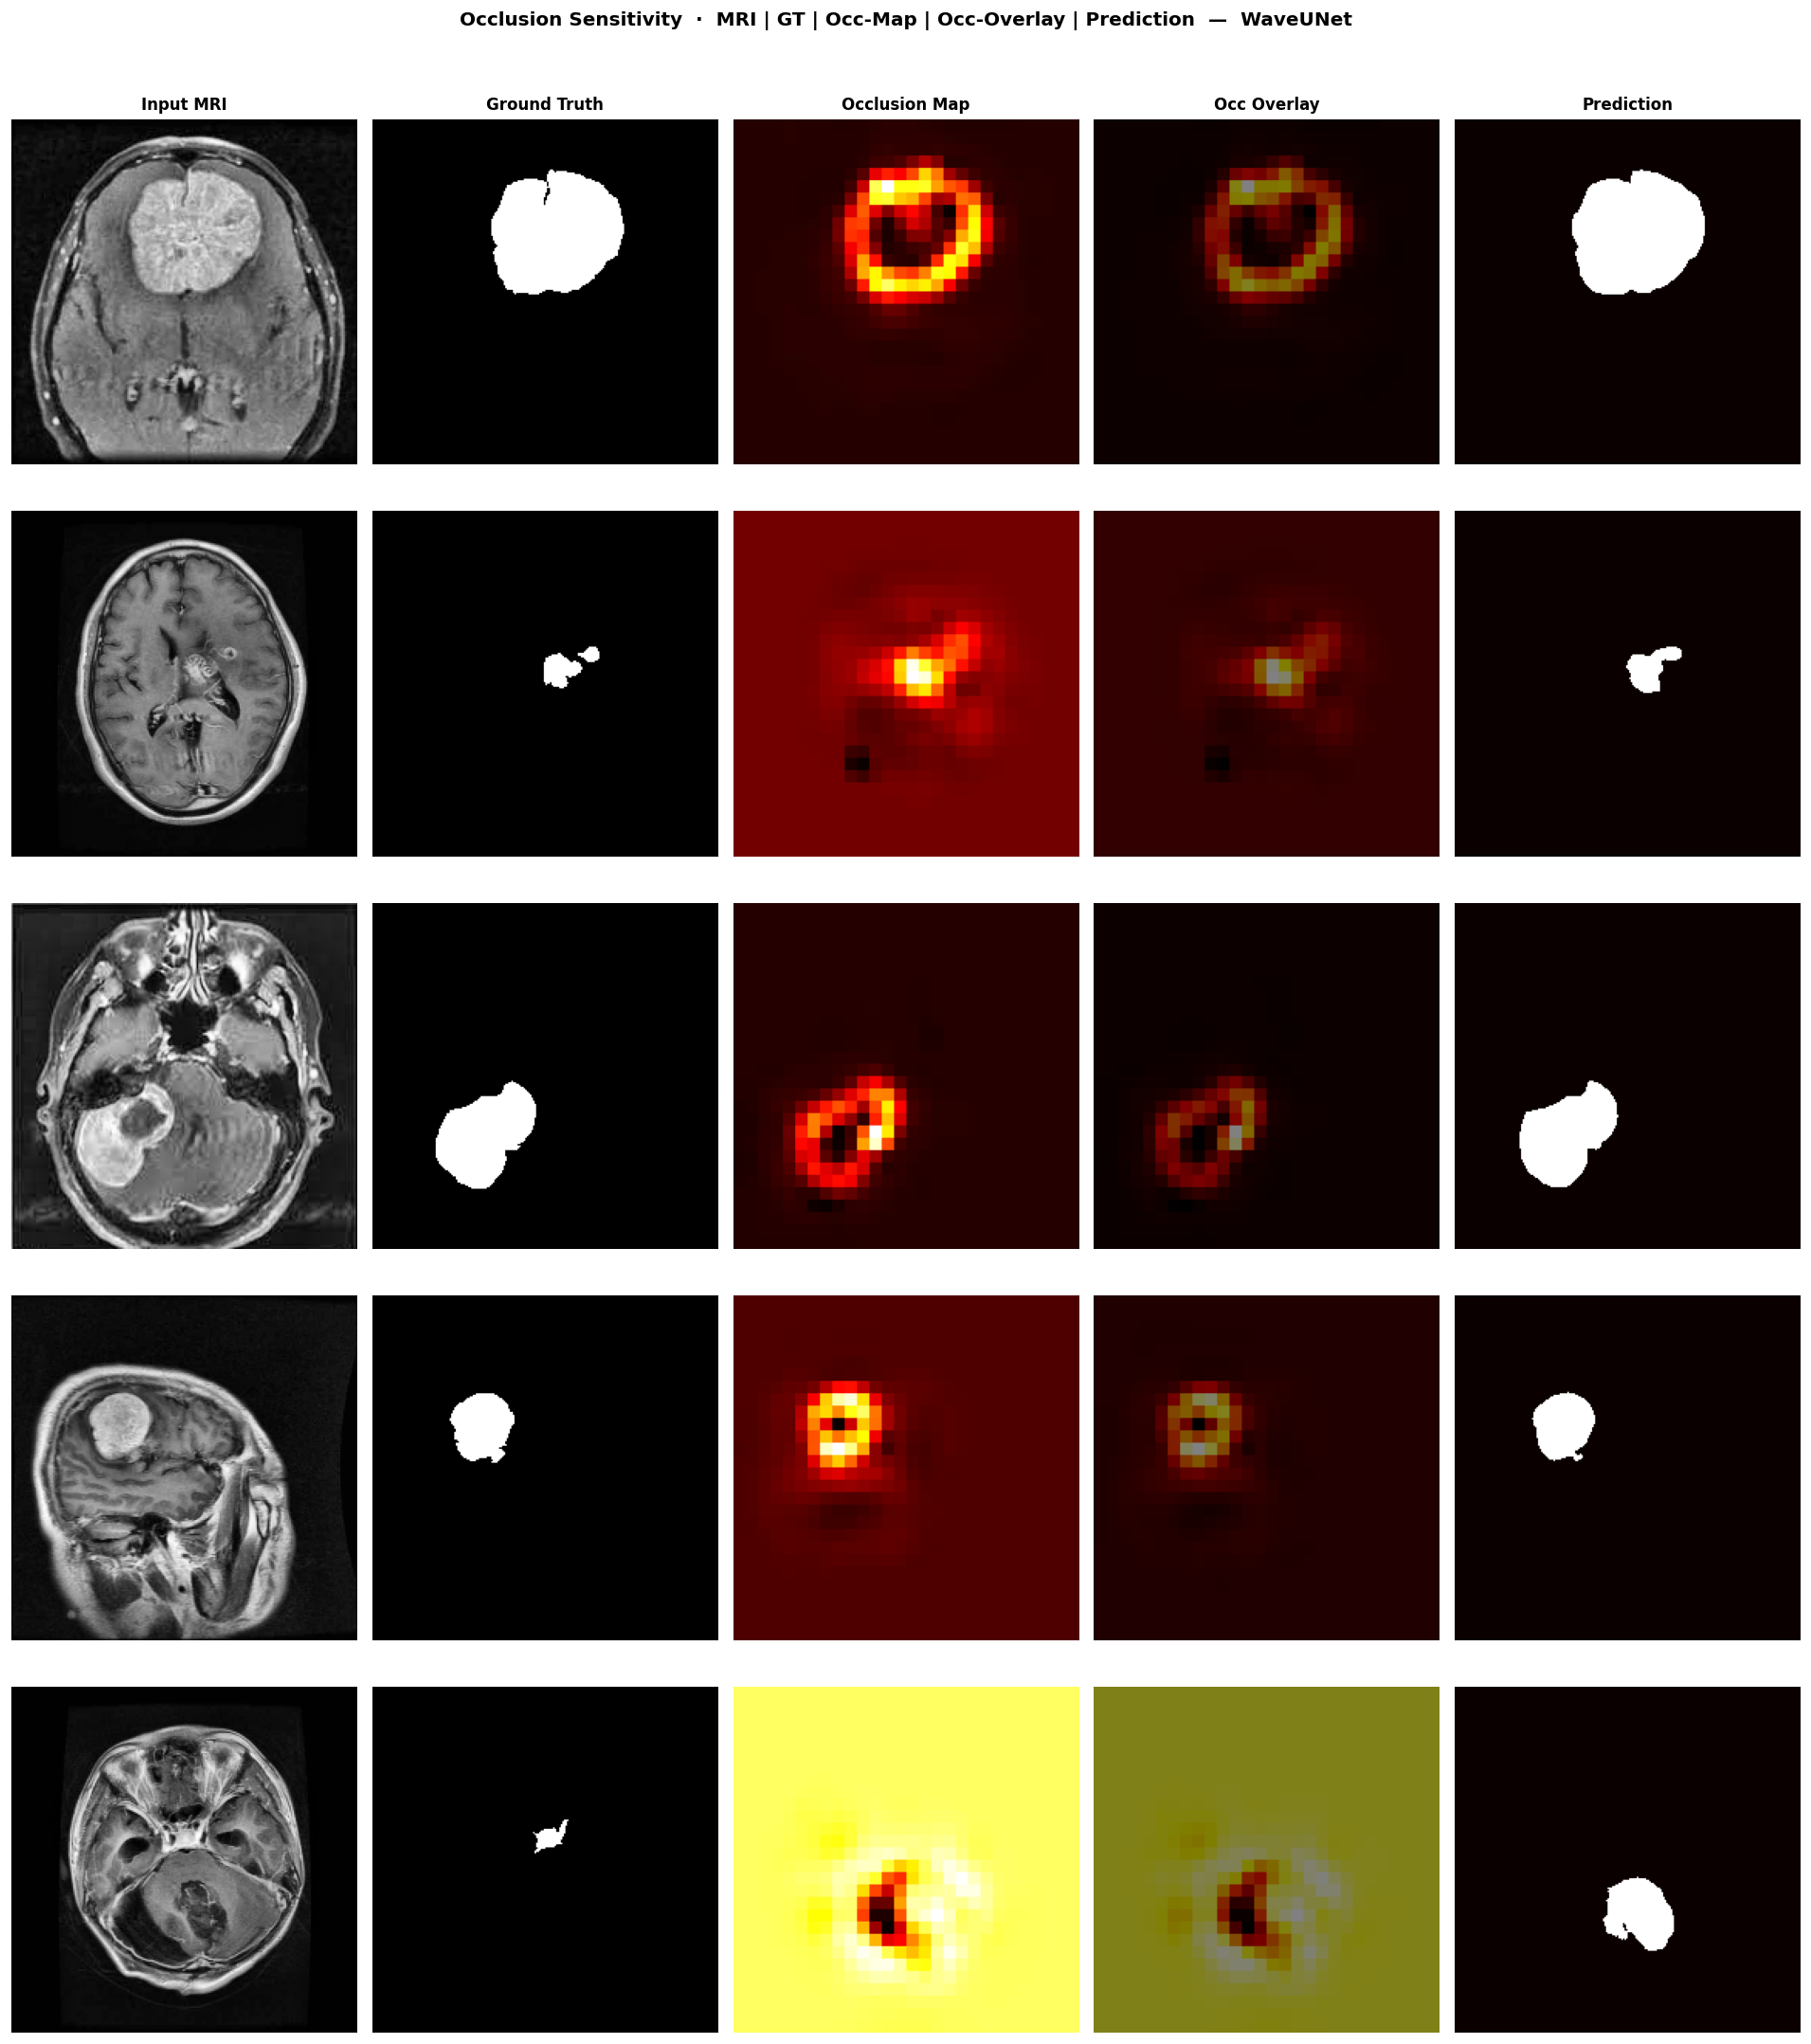

In [ ]:
@torch.no_grad()
def occlusion_sensitivity(model, img4_np, patch_size=16, stride=8, device=CFG.DEVICE):
    model.eval()
    H, W  = img4_np.shape[1], img4_np.shape[2]
    img_t = torch.from_numpy(img4_np).unsqueeze(0).float().to(device)
    base = torch.sigmoid(model(img_t)).mean().item()
    occ_map = np.zeros((H, W), dtype=np.float32)
    count = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occ = img_t.clone()
            occ[:, :, y:y+patch_size, x:x+patch_size] = 0.0
            drop = base - torch.sigmoid(model(occ)).mean().item()
            occ_map[y:y+patch_size, x:x+patch_size] += drop
            count  [y:y+patch_size, x:x+patch_size] += 1.0

    occ_map /= np.maximum(count, 1e-8)
    occ_map -= occ_map.min()
    if occ_map.max() > 1e-8: occ_map /= occ_map.max()
    return occ_map

_random.seed(CFG.SEED + 2)
_mid_occ = _all_sorted[1:-1]
_rand3_occ = _random.sample(_mid_occ, 3)
occ_5 = [_all_sorted[0]] + _rand3_occ + [_all_sorted[-1]]
labels_occ = ['Best'] + [f'Random {i+1}' for i in range(3)] + ['Worst']

print('Computing occlusion maps')
fig, axes = plt.subplots(5, 5, figsize=(16, 3.6 * 5))
fig.suptitle('Occlusion Sensitivity  ·  MRI | GT | Occ-Map | Occ-Overlay | Prediction  —  WaveUNet', fontsize=12, fontweight='bold', y=1.01)

for col, t in enumerate(['Input MRI', 'Ground Truth', 'Occlusion Map', 'Occ Overlay', 'Prediction']):
    axes[0][col].set_title(t, fontsize=10, fontweight='bold')

for row, (s, lbl) in enumerate(zip(occ_5, labels_occ)):
    img_np = s['image']
    img4_np = s['img4']
    occ_map = occlusion_sensitivity(model, img4_np)

    img_u8 = (img_np  * 255).clip(0, 255).astype(np.uint8)
    occ_u8 = (occ_map * 255).clip(0, 255).astype(np.uint8)
    occ_rgb = cv2.applyColorMap(occ_u8, cv2.COLORMAP_HOT)
    img_rgb = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2BGR)
    occ_ovl = cv2.addWeighted(img_rgb, 0.5, occ_rgb, 0.5, 0)
    occ_ovl = cv2.cvtColor(occ_ovl, cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(img_np, cmap='gray')
    axes[row][1].imshow(s['gt'], cmap='gray')
    axes[row][2].imshow(occ_map, cmap='hot')
    axes[row][3].imshow(occ_ovl)
    axes[row][4].imshow(s['pred'], cmap='hot')

    axes[row][0].set_ylabel(f'[{lbl}]\nDice={s["dice"]:.4f}', fontsize=9)
    for ax in axes[row]: ax.axis('off')
    print(f'  [{row+1}/5] {lbl} done')

plt.tight_layout()
plt.savefig('/kaggle/working/viz_occlusion_5.png', dpi=150, bbox_inches='tight')
plt.show()


##  Final Summary

In [ ]:
total_params, _ = count_params(model)
te_df = pd.DataFrame(te_records)

print('=' * 72)
print('FINAL SUMMARY — BRISC-25  WaveUNet Brain MRI Segmentation')
print('=' * 72)
print(f'  Best epoch       : {best_epoch} / {CFG.EPOCHS}')
print(f'  Total parameters : {total_params:,}  ({total_params/1e6:.1f} M)')
print(f'  Wavelet          : {CFG.WAVELET}  |  Levels: {CFG.WAVE_LEVELS}')
print(f'  Input channels   : {CFG.IN_CHANNELS} (original + LH + HL + HH sub-bands)')
print(f'  Image size       : {CFG.IMAGE_SIZE}x{CFG.IMAGE_SIZE}')
print(f'  Batch size       : {CFG.BATCH_SIZE}')
print(f'  Optimizer        : AdamW  (lr={CFG.LR}, wd={CFG.WEIGHT_DECAY})')
print(f'  Scheduler        : CosineAnnealingLR')
print()

metrics_map = {
    'Dice':'dice','IoU':'iou','HD95':'hd95',
    'Precision':'precision','Recall':'recall','Specificity':'specificity',
}
print(f"| {'Metric':<14} | {'Test Mean':>12} | {'Test Std':>10} |")
print(f"|{'-'*16}|{'-'*14}|{'-'*12}|")
for display, col in metrics_map.items():
    vals = te_df[col].dropna()
    print(f"| {display:<14} | {vals.mean():>12.4f} | {vals.std():>10.4f} |")

print()
print(f'  Best Val Dice    : {best_val_dice:.4f}')
print(f'  Checkpoint       : {CFG.BEST_CKPT}')
print('=' * 72)


FINAL SUMMARY — BRISC-25  WaveUNet Brain MRI Segmentation
  Best epoch       : 92 / 100
  Total parameters : 12,463,009  (12.5 M)
  Wavelet          : haar  |  Levels: 4
  Input channels   : 4 (original + LH + HL + HH sub-bands)
  Image size       : 224x224
  Batch size       : 8
  Optimizer        : AdamW  (lr=0.0003, wd=1e-05)
  Scheduler        : CosineAnnealingLR

| Metric         |    Test Mean |   Test Std |
|----------------|--------------|------------|
| Dice           |       0.8600 |     0.1724 |
| IoU            |       0.7835 |     0.1966 |
| HD95           |       7.1821 |    13.2333 |
| Precision      |       0.8713 |     0.1776 |
| Recall         |       0.8796 |     0.1741 |
| Specificity    |       0.9983 |     0.0031 |

  Best Val Dice    : 0.8673
  Checkpoint       : /kaggle/working/models/waveunet_best.pth
